In [1]:
# Show current directory
import os
curr_dir = os.getcwd()
print(curr_dir)
import json

c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\seizure_detection\snnTorch


In [2]:
# Add parent directory to path (To acess sntt_utils)
import sys

parent_dir = os.path.abspath(os.path.join(curr_dir, os.pardir))
sys.path.append(parent_dir)
print(sys.path)
# liset_path = os.path.abspath(os.path.join(curr_dir, '../liset_tk'))



['c:\\nrn\\lib\\python', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\python39.zip', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\DLLs', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples', '', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\win32\\lib', 'c:\\Users\\NCN\\miniconda3\\envs\\lava_snn_ripples\\lib\\site-packages\\Pythonwin', 'c:\\Users\\NCN\\Documents\\PedroFelix\\LAVA_SNN_ripples\\seizure_detection']



# Check if Cuda is available

In [3]:
import torch
import numpy as np

# Check CUDA Installation
print(torch.cuda.is_available())

# Get the number of available GPUs
num_gpus = torch.cuda.device_count()
print(f"Number of GPUs: {num_gpus}")

# Get information about each GPU
for i in range(num_gpus):
    device_props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}:")
    print(f"  Name: {device_props.name}")
    print(f"  Total memory: {device_props.total_memory / 1024**3:.2f} GB")
    print(f"  Multiprocessor count: {device_props.multi_processor_count}")
    print(f"  Major compute capability: {device_props.major}")
    print(f"  Minor compute capability: {device_props.minor}")

False
Number of GPUs: 0


## Define the Device that will be used to train the SNN


In [4]:
WINDOW_SIZE=200
PRED_CAUSALITY_WINDOW=5  # Causality between the prediction and the GT (in timesteps)

In [5]:
# Set the device to be used
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")     # torch.device("cpu") #

print("device: ", device)

device:  cpu


# Generate the SNN's Input Data and Labels (GT)
We need to transform the input data into a format that we can feed into the SNN. To allow learning through BPTT, we will split the spike trains into time windows of WINDOW_SIZE ms. Since a relevant HFO can occur in-between 2 time windows, we will introduce an overlap of INTERSECT_WINDOW_LEN ms between the time windows -- equal to the maximum duration of an HFO.

We are opting for this windowing strategy because it is a simple way to implement learning in the SNN. Another option would be to feed the data in real-time to the SNN without windows, but this would disable the possibility of having batch_size > 1.

# Split the Input into Time Windows and Calculate the Ground Truth

In [6]:
load=True
from up_dn_spikes.make_up_dn_iis import *
# Only run this block if first time
if 'windowed_input_dataa' not in locals():
    if load:
        # print(curr_dir)
        windowed_path=os.path.join(parent_dir,"up_dn_spikes","windowed_data")
        windowed_input_data = np.load(os.path.join(windowed_path,"windowed_input_data.npy"))
        windowed_gt = np.load(os.path.join(windowed_path,"windowed_gt.npy"))
        filtered_windows=np.load(os.path.join(windowed_path,"filtered_windows.npy"))
        ripple_ids= np.load(os.path.join(windowed_path,"ripple_ids.npy"))
        print("windowed_input_data loaded from disk")
    else:
        print("Get the Data first you idiot")
else:
    print("windowed_input_data already loaded")

print("windowed_input_data shape: ", windowed_input_data.shape)
print("windowed_gt shape: ", windowed_gt.shape)
print("filtered_windows shape: ", filtered_windows.shape)
print("ripple_ids shape: ", ripple_ids.shape)

windowed_input_data loaded from disk
windowed_input_data shape:  (127455, 200, 2)
windowed_gt shape:  (127455,)
filtered_windows shape:  (127455, 200)
ripple_ids shape:  (127455,)


The code block above outputs:

1. A list of time windows of shape =  `(num_windows, window_size, input_neurons) -- windowed_input_data`
2. A list of labels of shape = `(num_windows, ) -- windowed_gt`

## Process Input data
Take only the channels that display the maximum number of spikes for each ripple


In [7]:
is_hfo = windowed_gt >= 0
hfo_windows = windowed_input_data[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = windowed_input_data[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = windowed_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = windowed_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2) 

hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
og_total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
og_total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts
average_total_counts= (np.sum(og_total_hfo_counts)+np.sum(og_total_nonhfo_counts))/len(windowed_input_data)

# Print the average counts
average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(og_total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(og_total_nonhfo_counts)
median_hfo_counts=np.median(og_total_hfo_counts)
median_nonhfo_counts=np.median(og_total_nonhfo_counts)


In [8]:
# max_channel_num=3
# windowed_input_data,windowed_gt,ripple_ids=only_some_channels_per_ripple(windowed_input_data,windowed_gt,ripple_ids,max_channel_num)

In [ ]:
# # print(average_total_hfo_counts)
# # thresholds=[average_total_counts,average_total_hfo_counts*20]


# nonhfo_threshold = np.percentile(og_total_nonhfo_counts, 90) 
# hfo_activity_threshold = np.percentile(og_total_hfo_counts, 50) 
# thresholds = [nonhfo_threshold, hfo_activity_threshold]

# # thresholds=[100,50]
# # p2_windowed_input_data,p2_windowed_gt,p2_ripple_ids=min_max_spike_threshold(p1_windowed_input_data,p1_windowed_gt,
# #                                                                          p1_ripple_ids,MEAN_DETECTION_OFFSET,thresholds)

# p2_windowed_input_data,p2_windowed_gt,p2_ripple_ids=min_max_spike_threshold_prob(windowed_input_data,windowed_gt,
#                                                                          ripple_ids,thresholds,max_prob=0.9,multiplier=2,decay=3,drop_fn=drop_exponential)

False Negative Removed (Prob 0.47) - Spikes: 5.0
False Positive Removed (Prob 0.41) - Spikes: 4.0
False Negative Removed (Prob 0.86) - Spikes: 8.0
False Negative Removed (Prob 0.70) - Spikes: 6.0
False Negative Removed (Prob 0.81) - Spikes: 7.0
False Negative Removed (Prob 0.47) - Spikes: 5.0
False Negative Removed (Prob 0.86) - Spikes: 8.0
False Negative Removed (Prob 0.86) - Spikes: 8.0
False Positive Removed (Prob 0.63) - Spikes: 3.0
False Positive Removed (Prob 0.41) - Spikes: 4.0
False Negative Removed (Prob 0.88) - Spikes: 9.0
False Negative Removed (Prob 0.90) - Spikes: 14.0
False Negative Removed (Prob 0.90) - Spikes: 11.0
False Negative Removed (Prob 0.90) - Spikes: 12.0
False Negative Removed (Prob 0.88) - Spikes: 9.0
False Negative Removed (Prob 0.90) - Spikes: 14.0
False Negative Removed (Prob 0.86) - Spikes: 8.0
False Negative Removed (Prob 0.88) - Spikes: 9.0
False Negative Removed (Prob 0.90) - Spikes: 12.0
False Negative Removed (Prob 0.88) - Spikes: 9.0
False Negative 

In [10]:
# Define mask for windows with an HFO (spike time >= 0) in the GT

# TODO: Some ripples are detect outside the window - this is not compatible...
# I have changed it to be 180 - might still be too close to the window size
# Mesquita had clamped it differently.

# See GT Class Distribution
# Set print options to see more elements
np.set_printoptions(linewidth=100, threshold=50, edgeitems=20)
print(f"Ground Truth Class Distribution: {np.unique(windowed_gt, return_counts=True)}")



GT_HFO_MASK = windowed_gt >= 0
# print(windowed_gt[0:1000])
# Define the number of windows with an HFO
num_hfo_windows = np.sum(GT_HFO_MASK)
print(f"Number of windows with an HFO: {num_hfo_windows}")
print(f"Percentage of windows with an HFO: {num_hfo_windows / windowed_gt.shape[0] * 100:.2f}%")

Ground Truth Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 160., 161., 162., 163., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 179.], dtype=float32), array([109685,    254,    205,    297,    273,    198,    183,    293,    181,    190,    174,
          174,    187,    237,    256,    186,    194,    273,    190,     76, ...,     49,     48,
           44,     58,    116,    105,     67,     65,    112,     27,     76,     63,     44,
           56,     87,     31,     77,     75,     82,     66], dtype=int64))
Number of windows with an HFO: 17770
Percentage of windows with an HFO: 13.94%


**Note**: It's a good sign that the GT time is distributed along the time window.

For example, if the GT annotation could only occur on the first 25% timesteps of the window, it could converge the network toward not spiking or spiking initially to minimize the loss.


**QUESTION** : 
 - How to deal with edge cases? 
 - How to deal with the fact that there are a lot of them at the limit (175-180 ms)

## Interpreting the Ground Truth Timestamp values
- Lower limit: `MEAN_HFO_DURATION`
- Upper limit: `RIPPLE[1]` (actually WINDOW_SIZE)

Such that we only consider the ripples that are completely within the window.

The Marker annotation is a timestamp that indicates the approximated end of the HFO event. It is bounded upwards and downwards by the variables mentioned above.

# Class Balancing
We can see that Class 0 (No HFO) is much more frequent than Class 1 (HFO). This is expected since HFOs are rare events. However, we need to be careful with **class imbalance**, as it can lead to model overfitting and poor generalization.

- 8.58% of Windows -> HFO
- 91.42% of Windows -> No HFO

In [24]:
from snnTorch.utils.training import undersample_majority, oversample_minority
intermediate_input, intermediate_gt = windowed_input_data, windowed_gt  # Default: No Balancing
balance=True
if balance:
    multiplier=1
    mult_minority=0.5
    intermediate_input, intermediate_gt = undersample_majority(windowed_input_data, windowed_gt, c1_mask=GT_HFO_MASK,multiplier=multiplier,mult_minority=mult_minority)  

# Print the number of samples in each class
print(f"Intermediate GT Class Distribution: {np.unique(intermediate_gt, return_counts=True)}")
print(f"Intermediate Window Input Data Shape: {intermediate_input.shape}")


Intermediate GT Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 160., 161., 162., 163., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 179.], dtype=float32), array([8885,  131,  102,  153,  133,   93,   91,  148,   87,   94,   82,   94,  102,  112,  133,
         86,   97,  124,  105,   42, ...,   24,   22,   23,   29,   61,   57,   31,   37,   65,
         15,   42,   28,   26,   30,   42,   10,   42,   41,   41,   36], dtype=int64))
Intermediate Window Input Data Shape: (17770, 200, 2)


In [25]:
# Find the indices to sort the input data by the nº of UP/DN spikes (descending order)
intermediate_sorted_indices = np.argsort(
    -(np.sum(intermediate_input[:, :, 0], axis=1) + np.sum(intermediate_input[:, :, 1], axis=1)), 
)

# Sort the input data and GT data by the sorted indices
intermediate_sorted_input = intermediate_input[intermediate_sorted_indices]
intermediate_sorted_gt = intermediate_gt[intermediate_sorted_indices]

print(f"intermediate_sorted_indices: {intermediate_sorted_indices}")
print(f"intermediate_sorted_input: {intermediate_sorted_input.shape} | intermediate_sorted_gt: {intermediate_sorted_gt.shape}")
print(f"intermediate_sorted_gt preview: {intermediate_sorted_gt[:10]}")
print(f"GT first window: {intermediate_sorted_gt[0]} | GT last window: {intermediate_sorted_gt[-1]}")

intermediate_sorted_indices: [16348 10006 13599 17592 15794 17610 17279 17274  4126 16356  4122 13294 16288 16284 17281 16358
  6167  5557 17599  5558 ...  5891 13401 13399 13398 13397  5896 13395  5897  6229 13393 13391
 13390 13389 13388 13387  5898 13384 13381 13392 17769]
intermediate_sorted_input: (17770, 200, 2) | intermediate_sorted_gt: (17770,)
intermediate_sorted_gt preview: [ 23.  33.  -1.  23.  22.  22.  20.  73.  21. 107.]
GT first window: 23.0 | GT last window: -1.0


In [26]:
# value=5000
# is_hfo=intermediate_sorted_gt >= 0
# hfo_windows=intermediate_sorted_input[is_hfo][:value]       # shape: (N_HFO, 180, 2)
# hfo_gt=intermediate_sorted_gt[is_hfo][:value]
# non_hfo_windows=intermediate_sorted_input[~is_hfo]
# non_hfo_gt=intermediate_sorted_gt[~is_hfo]

# all_windows=np.concatenate((hfo_windows,non_hfo_windows),axis=0)
# all_gt=np.concatenate((hfo_gt,non_hfo_gt),axis=0)
# gt_mask=all_gt >= 0

# if balance:
#     multiplier=1
#     intermediate_input, intermediate_gt = undersample_majority(all_windows, all_gt, c1_mask=gt_mask,multiplier=multiplier)  
# print(f"Final GT Class Distribution: {np.unique(intermediate_gt, return_counts=True)}")
# print(f"Final Window Input Data Shape: {intermediate_input.shape}")
# print(f"Number of windows with an HFO: {np.sum(intermediate_gt >= 0)}")
# print(f"Total Number of windows: {len(intermediate_gt)}")
num_hfo_windows = np.sum(intermediate_gt >= 0)

## Split sorted GT Samples into Time bins to select number of non-HFO Samples

In [27]:
# Get the max. number of elements in a bin excluding the -1 bin
# unique_bins idx 0 is the -1 bin
# Only select MAJORITY_FACTOR * max_bin_size samples with gt=-1
MAJORITY_FACTOR = 1# 2 # 1 
# max_bin_size = int(np.sum(unique_counts[unique_bins > 0]) / MAJORITY_FACTOR) #all ripples
max_bin_size=int(num_hfo_windows//MAJORITY_FACTOR *multiplier)
print(f"Max bin size: {max_bin_size}")

Max bin size: 8885


In [28]:
# If I just want to take some GT=-1 samples

ALL_GT_MINUS_1_MASK = intermediate_gt==-1

print(f"Selecting {max_bin_size} samples with GT=-1")
""" 
Since intermediate_sorted_input contains the sorted input data, we can select the first max_bin_size samples with gt=-1.
This way, the selected GT=-1 samples will contain the most UP/DN spikes, forcing the network to differentiate the HFO events
from the non-HFO events with more UP/DN spikes.
"""
GT_MINUS_1_INDICES = np.where(ALL_GT_MINUS_1_MASK)[0][:max_bin_size]
print(f"GT_MINUS_1_INDICES: {GT_MINUS_1_INDICES}")
print(len(GT_MINUS_1_INDICES), "GT=-1 samples selected")  
# Define Mask for the selected indices with GT=-1
GT_MINUS_1_MASK = np.zeros(ALL_GT_MINUS_1_MASK.shape, dtype=bool)   # Create a mask of the same shape as the input data
for selected_idx in GT_MINUS_1_INDICES:
    GT_MINUS_1_MASK[selected_idx] = True   # Set the selected indices to True

# Define Mask for the definitive windows
BALANCED_WINDOWS_MASK = GT_MINUS_1_MASK | (~ALL_GT_MINUS_1_MASK)   # Get the indices some samples with gt=-1 + gt!=-1    
print(f"BALANCED_WINDOWS_MASK: {np.sum(BALANCED_WINDOWS_MASK)} windows selected")

# Define the Balanced input and gt data
balanced_input = intermediate_input[BALANCED_WINDOWS_MASK]
balanced_gt = intermediate_gt[BALANCED_WINDOWS_MASK]

Selecting 8885 samples with GT=-1
GT_MINUS_1_INDICES: [    0     1     2     3     6    13    28    80    89    90    91    92    93    94    95    96
    97    98    99   100 ... 17739 17751 17752 17753 17754 17755 17756 17757 17758 17759 17760
 17761 17762 17763 17764 17765 17766 17767 17768 17769]
8885 GT=-1 samples selected
BALANCED_WINDOWS_MASK: 17770 windows selected


## Evaluate the Split

In [29]:
indices=np.arange(0,1000)
sorted_gt_distribution=balanced_gt[indices]
print(f"Sorted GT Distribution: {np.unique(sorted_gt_distribution, return_counts=True)}")
# print(f"Total Spikes per window: {total_spikes_per_window[indices]}")

Sorted GT Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  33.,  34.,  35.,
        36.,  38.,  39.,  40.,  41., ..., 150., 152., 153., 154., 156., 157., 158., 161., 162.,
       163., 164., 165., 167., 168., 169., 173., 174., 176., 177., 179.], dtype=float32), array([473,   2,   9,   9,   6,   4,   1,  11,   3,   6,  11,   5,   6,   8,   4,   5,   7,   2,
         5,   2, ...,   5,   3,   2,   4,   4,   5,   4,   2,   4,   5,   5,   2,   5,   2,   5,
         1,   6,   4,   3,   7], dtype=int64))


In [30]:
is_hfo = balanced_gt >= 0
hfo_windows = balanced_input[is_hfo]       # shape: (N_HFO, 180, 2)
non_hfo_windows = balanced_input[~is_hfo]  # shape: (N_nonHFO, 180, 2)
windowed_gt_hfo = balanced_gt[is_hfo]       # shape: (N_HFO, 180, 2)
windowed_gt_non_hfo = balanced_gt[~is_hfo]  # shape: (N_nonHFO, 180, 2) 

In [31]:
# Sum over time axis
hfo_up_counts = np.sum(hfo_windows[:, :, 0], axis=1)
hfo_down_counts = np.sum(hfo_windows[:, :, 1], axis=1)
og_total_hfo_counts= hfo_up_counts + hfo_down_counts
nonhfo_up_counts = np.sum(non_hfo_windows[:, :, 0], axis=1)
nonhfo_down_counts= np.sum(non_hfo_windows[:, :,1], axis=1)
og_total_nonhfo_counts = nonhfo_up_counts + nonhfo_down_counts
average_total_counts= (np.sum(og_total_hfo_counts)+np.sum(og_total_nonhfo_counts))/len(balanced_input)

# Print the average counts
average_hfo_up_counts = np.mean(hfo_up_counts)
average_hfo_down_counts = np.mean(hfo_down_counts)
average_total_hfo_counts = np.mean(og_total_hfo_counts)
average_nonhfo_up_counts = np.mean(nonhfo_up_counts)
average_nonhfo_down_counts = np.mean(nonhfo_down_counts)
average_total_nonhfo_counts = np.mean(og_total_nonhfo_counts)
median_hfo_counts=np.median(og_total_hfo_counts)
median_nonhfo_counts=np.median(og_total_nonhfo_counts)
print(f"Average HFO Up Counts: {average_hfo_up_counts}")
print(f"Average HFO Down Counts: {average_hfo_down_counts}")
print(f"Average Total HFO Counts: {average_total_hfo_counts}")
print(f"Average Non-HFO Up Counts: {average_nonhfo_up_counts}")
print(f"Average Non-HFO Down Counts: {average_nonhfo_down_counts}")
print(f"Average Total Non-HFO Counts: {average_total_nonhfo_counts}")
print(f"Average Total Counts: {average_total_counts}")
print(f"Median HFO Counts: {median_hfo_counts}")
print(f"Median Non-HFO Counts: {median_nonhfo_counts}")



Average HFO Up Counts: 3.4936409679234663
Average HFO Down Counts: 3.3791783905458637
Average Total HFO Counts: 6.8728193584693305
Average Non-HFO Up Counts: 1.2031513787281936
Average Non-HFO Down Counts: 1.164321890827237
Average Total Non-HFO Counts: 2.3674732695554304
Average Total Counts: 4.620146314012381
Median HFO Counts: 5.0
Median Non-HFO Counts: 2.0


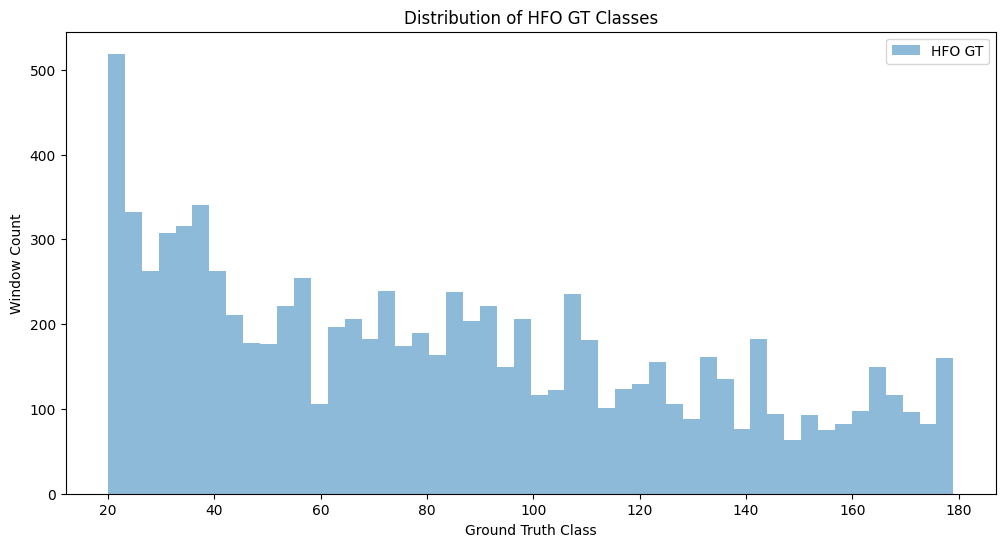

In [32]:
plt.subplots(figsize=(12, 6))
plt.hist(windowed_gt_hfo, bins=50, alpha=0.5, label='HFO GT')
plt.legend()
plt.title('Distribution of HFO GT Classes')
plt.xlabel('Ground Truth Class')
plt.ylabel('Window Count')
plt.show()

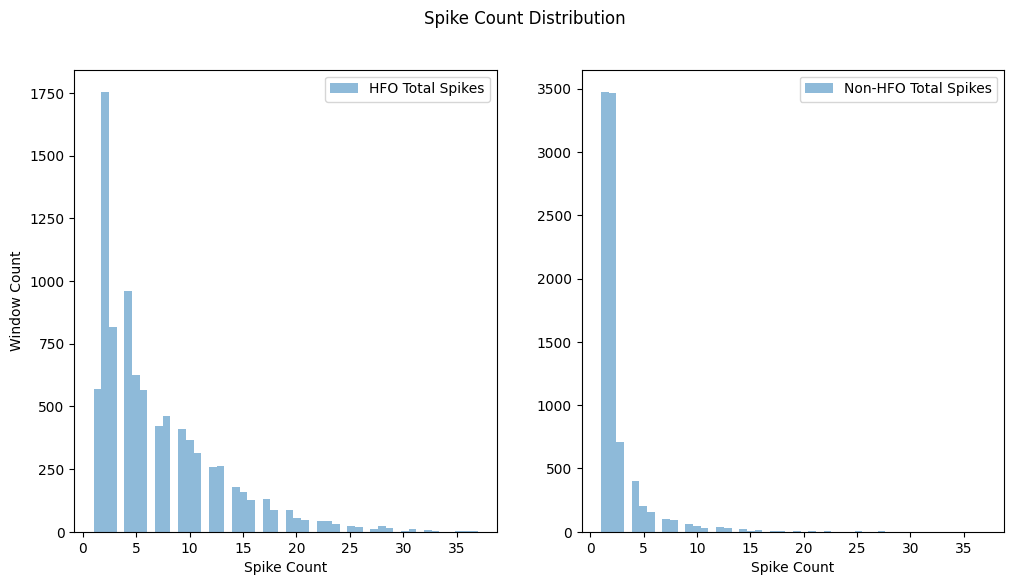

In [33]:
plt.subplots(1,2, figsize=(12, 6))
plt.suptitle('Spike Count Distribution')
plt.subplot(1, 2, 1)
plt.hist(og_total_hfo_counts,bins=50, alpha=0.5, label='HFO Total Spikes')
plt.xlabel('Spike Count')
plt.ylabel('Window Count')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(og_total_nonhfo_counts, bins=50, alpha=0.5, label='Non-HFO Total Spikes')
plt.legend()
plt.xlabel('Spike Count')
plt.show()

In [34]:
hist_ripples = np.histogram(og_total_hfo_counts, bins=100)
hist_nonripples = np.histogram(og_total_nonhfo_counts, bins=100)

dic={}
config=evaluate_histogram(hist_ripples,hist_nonripples,dic)

Bhattacharyya Distance: 0.2163
KL Divergence: 1.1311
Earth Mover’s Distance: 12.4403
Chi-Square Statistic: 37602704.9069, p-value: 0.0000


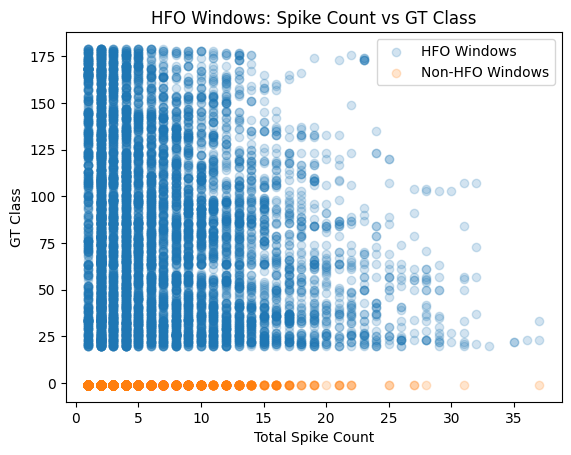

In [35]:
plt.scatter(og_total_hfo_counts,windowed_gt_hfo, alpha=0.2, label='HFO Windows')
plt.scatter(og_total_nonhfo_counts,windowed_gt_non_hfo, alpha=0.2, label='Non-HFO Windows')
plt.xlabel('Total Spike Count')
plt.ylabel('GT Class')
plt.title('HFO Windows: Spike Count vs GT Class')
plt.legend(loc='upper right')
plt.show()

In [36]:
# Print the number of samples in each class
print(f"Balanced GT Class Distribution: {np.unique(balanced_gt, return_counts=True)}")
print(f"Balanced Window Input Data Shape: {balanced_input.shape}")
hfo_percent = np.sum(balanced_gt >= 0) / balanced_gt.shape[0] * 100
print(f"Percentage of windows with an HFO: {hfo_percent:.2f}%")
print(f"Baseline Accuracy (No Spiking): {100 - hfo_percent:.2f}%")

Balanced GT Class Distribution: (array([ -1.,  20.,  21.,  22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,
        34.,  35.,  36.,  37.,  38., ..., 160., 161., 162., 163., 164., 165., 166., 167., 168.,
       169., 170., 171., 172., 173., 174., 175., 176., 177., 178., 179.], dtype=float32), array([8885,  131,  102,  153,  133,   93,   91,  148,   87,   94,   82,   94,  102,  112,  133,
         86,   97,  124,  105,   42, ...,   24,   22,   23,   29,   61,   57,   31,   37,   65,
         15,   42,   28,   26,   30,   42,   10,   42,   41,   41,   36], dtype=int64))
Balanced Window Input Data Shape: (17770, 200, 2)
Percentage of windows with an HFO: 50.00%
Baseline Accuracy (No Spiking): 50.00%


In [37]:
from pandas import cut
# Define GT time bins to stratify the GT events
num_bins = 12
# Define bins explicitly to handle the -1 GT
bin_edges = np.linspace(intermediate_sorted_gt[intermediate_sorted_gt >= 0].min(), intermediate_sorted_gt.max(), num_bins)
# Add the -1 bin edge
bin_edges = np.insert(bin_edges, 0, -1.1)   # Add edge below -1
bin_edges = np.unique(bin_edges)   # Remove duplicates
print(bin_edges)

binned_gt = cut(balanced_gt, bins=bin_edges, labels=False, include_lowest=True)

# Print the number of samples in each bin
unique_bins, unique_counts = np.unique(binned_gt, return_counts=True)
print(f"Binned GT Class Distribution: {np.unique(binned_gt, return_counts=True)}")
print(f"There are {len(unique_bins)} bins")

[ -1.1         20.          34.45454545  48.90909091  63.36363636  77.81818182  92.27272727
 106.72727273 121.18181818 135.63636364 150.09090909 164.54545455 179.        ]
Binned GT Class Distribution: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int64), array([9016, 1510, 1090,  845,  912,  942,  732,  710,  560,  501,  409,  543], dtype=int64))
There are 12 bins


## Split the Data into Training and Testing Sets
Since we split the input into windows, we can use it without worrying about sample order.

In [38]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Split the data into training and testing
train_proportion = 0.85      # Portion of the data to be used for training

train_data, test_data, train_gt, test_gt = train_test_split(
    balanced_input, balanced_gt,
    train_size=train_proportion, 
    stratify=binned_gt,    # Maintain the class balance based on the labels (balanced_gt)
    shuffle=True
)

print("Training Data Shape: ", train_data.shape)
print("Training Ground Truth Shape: ", train_gt.shape)
print("Testing Data Shape: ", test_data.shape)
print("Testing Ground Truth Shape: ", test_gt.shape)


Training Data Shape:  (15104, 200, 2)
Training Ground Truth Shape:  (15104,)
Testing Data Shape:  (2666, 200, 2)
Testing Ground Truth Shape:  (2666,)


In [39]:
# Print the number of input activations in the training and testing data
print("Number of Input Activations in Training Data: ", np.sum(train_data))
print("Number of Input Activations in Testing Data: ", np.sum(test_data))

# Print the Number Annotations in the training and testing data
print("Number of HFO Samples in Training Data: ", np.sum(train_gt >= 0))
print("Number of HFO Samples in Testing Data: ", np.sum(test_gt >= 0))

Number of Input Activations in Training Data:  69575.0
Number of Input Activations in Testing Data:  12525.0
Number of HFO Samples in Training Data:  7556
Number of HFO Samples in Testing Data:  1329


In [41]:
from torch.utils.data import TensorDataset, DataLoader
save_load_path = os.path.join(curr_dir, "train_test_data")
print(f"Save/Load Path: {save_load_path}")
load_data=True
id="4"
if load_data:
    print("Loading training and test tensors from disk...")
    train_data_tensor = torch.load(os.path.join(save_load_path,f"train_data_{id}.pt"))
    train_gt_tensor = torch.load(os.path.join(save_load_path,f"train_labels_{id}.pt"))
    test_data_tensor =  torch.load( os.path.join(save_load_path,f"test_data_{id}.pt"))
    test_gt_tensor = torch.load(os.path.join(save_load_path,f"test_labels_{id}.pt"))
else:
    print("Converting training and test data to PyTorch tensors...")
    # Convert numpy arrays to PyTorch tensors
    train_data_tensor = torch.tensor(train_data, dtype=torch.float32)
    train_gt_tensor = torch.tensor(train_gt, dtype=torch.float32)
    test_data_tensor = torch.tensor(test_data, dtype=torch.float32)
    test_gt_tensor = torch.tensor(test_gt, dtype=torch.float32)
# Save training and test tensors
save_data=False
if save_data:
    print("Saving training and test tensors...")
    
    os.makedirs(save_load_path, exist_ok=True)
    torch.save(train_data_tensor, os.path.join(save_load_path,f"train_data_{id}.pt"))
    torch.save(train_gt_tensor, os.path.join(save_load_path,f"train_labels_{id}.pt"))
    torch.save(test_data_tensor, os.path.join(save_load_path,f"test_data_{id}.pt"))
    torch.save(test_gt_tensor, os.path.join(save_load_path,f"test_labels_{id}.pt"))

Save/Load Path: c:\Users\NCN\Documents\PedroFelix\LAVA_SNN_ripples\seizure_detection\snnTorch\train_test_data
Loading training and test tensors from disk...


In [42]:
from snnTorch.utils.training import set_seed
SEED=5
set_seed(SEED)  # Or any integer
g = torch.Generator().manual_seed(SEED)

In [45]:
# Create a Tensor Dataset
train_dataset = TensorDataset(train_data_tensor, train_gt_tensor)
test_dataset = TensorDataset(test_data_tensor, test_gt_tensor)

# Define the batch size
batch_size = 256 #64 #32 # 2

# Create Data Loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,   # Do we want to force training one by one, i.e., batch_size=1?
    shuffle=True,
    generator=g,   # TODO: We are shuffling because each window resets the state of the network so it should not matter. Might not be the case for RNNs!!
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
    generator=g, 
)

In [46]:

# Show how many batches are in the training and testing data
print("Number of Training Batches: ", len(train_loader))
print("Number of Testing Batches: ", len(test_loader))

Number of Training Batches:  59
Number of Testing Batches:  11


## Define the Network
### Define the Loss Function

In [47]:
from snntorch import functional as SF
from snnTorch.utils.loss import mse_temporal_loss_penalty, first_spike_acc
from snnTorch.utils.my_loss import mse_temporal_loss_penaltyfn_fp,my_first_spike_acc
'''
Define the loss function
Let's use the mse_temporal_loss - Mean Squared Error Loss Temporal Loss.

Forward function:
Parameters:
    - output: Predictions of the network - First spike time of each output neuron.
        shape: torch.Tensor shape=(batch_size, num_classes) 
    - target:  Ground truth of the network - First spike time of each output neuron.
        shape: torch.Tensor shape=(batch_size, num_timesteps)
Returns:
    - loss: The loss value 
        shape: torch.Tensor shape=()

The loss function calculates the MSE loss of the first spike time of each output neuron.
If the output neuron spikes within the tolerance window, the loss is 0.
If the output neuron does not spike -> Considers it to spike at the last timestep and calculates the loss accordingly.
Note: The spike time is divided by the number of timesteps to normalize it between 0 and 1 -> Loss gets pretty low values
'''
# PENALTY_FACTOR = 2    # 1.5  # 1    # Penalty factor for the loss function (Extreme cases)


# loss_fn = mse_temporal_loss_penalty(
#     # target_is_time=True -> Target is the spike time (time step) of each output neuron. If false, the target is the gt class and the spike time of each class is fixed
#     target_is_time=True,
#     
# =PRED_GT_TOLERANCE,       # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
#     reduction='mean',        # Average the loss across the batch
#     penalty_factor=PENALTY_FACTOR,
#     normalize=False, # True      # Whether to normalize the loss by the number of timesteps 
# )

""" loss_fn = SF.mse_temporal_loss(
    target_is_time=True,
    tolerance=PRED_GT_TOLERANCE,       # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
    reduction='mean'  # 'mean',          # Average the loss across the batch OR Sum the loss across the batch
) """

PRED_GT_TOLERANCE=20  # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
fn_penalty_factor=1 # Penalty factor for the false negative loss (if the output neuron does not spike when it should)
fp_penalty_factor=1 # Penalty factor for the false positive loss (if the output neuron spikes when it should not)
loss_multiplier_negatives=1 # Multiplier for the loss of the negative samples (GT=-1) - This is used to balance the loss between positive and negative samples

loss_fn = mse_temporal_loss_penaltyfn_fp(
    # target_is_time=True -> Target is the spike time (time step) of each output neuron. If false, the target is the gt class and the spike time of each class is fixed
    target_is_time=True,
    tolerance=PRED_GT_TOLERANCE,       # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
    reduction='mean',        # Average the loss across the batch
    fn_penalty_factor=fn_penalty_factor,  # Penalty factor for the false negative loss (if the output neuron does not spike when it should)
    fp_penalty_factor=fp_penalty_factor,  # Penalty factor for the false positive loss (if the output neuron spikes when it should not)
    loss_multiplier_negatives=loss_multiplier_negatives,  # Multiplier for the loss of the negative samples (GT=-1) - This is used to balance the loss between positive and negative samples
    normalize=True, # True      # Whether to normalize the loss by the number of timesteps 
)



##  Define the Parameters of the Layers


In [48]:
import snntorch as snn
import torch.nn as nn
from snntorch import surrogate

# Global Parameters
v_thr = 1.0

# Define the surrogate gradient function to propagate spikes through the network
spike_grad = surrogate.fast_sigmoid()   # surrogate.atan()  # TODO: Try other surrogate from paper   

# Parameters for LIF neurons
# TODO: Make parameters learnable or at least distribute them in a better way

# Define the distribution for the parameters (alpha and beta)
alpha_mean, alpha_std = 0.5, 0.2    
beta_mean, beta_std = 0.5, 0.2

In [49]:
# Parameters for Dense Layers
inputDataDim = 2 # UP DN   # max_channel_idx - min_channel_idx + 1    # Number of input channels

input_to_hidden = (inputDataDim, 8) # 24 # 16 # TODO: Increase the size of this layer # (inputDataDim, 100) # (inputDataDim, 500)  # Number of neurons in the first Fully-Connected Layer

hiddenL2Dim = (input_to_hidden[1], input_to_hidden[1])  # Number of neurons in the Recurrent Fully-Connected Layer (L2)

hiddenL3Dim = (input_to_hidden[1], 6)  # 16 # Number of neurons in the Fully-Connected Layer (L3)

hiddenL4Dim = (hiddenL3Dim[1], input_to_hidden[1])  # Number of neurons in the Recurrent Fully-Connected Layer (L4)

hidden_to_out = (hiddenL3Dim[1], 1)  # Number of neurons in the Output Fully-Connected Layer
# In this case, we only need 1 output neuron -> Fires when HFO is detected

In [50]:
# Generate a random distribution for the current and membrane decays
alpha_lif1 = torch.normal(mean=torch.full(size=(input_to_hidden[1],), fill_value=alpha_mean), std=torch.full(size=(input_to_hidden[1],), fill_value=alpha_std))
beta_lif1 = torch.normal(mean=torch.full(size=(input_to_hidden[1],), fill_value=beta_mean), std=torch.full(size=(input_to_hidden[1],), fill_value=beta_std))
alpha_lif2 = torch.normal(mean=torch.full(size=(hiddenL3Dim[1],), fill_value=alpha_mean), std=torch.full(size=(hiddenL3Dim[1],), fill_value=alpha_std))
beta_lif2 = torch.normal(mean=torch.full(size=(hiddenL3Dim[1],), fill_value=beta_mean), std=torch.full(size=(hiddenL3Dim[1],), fill_value=beta_std))

# Clip the value to be positive
TIME_CONSTANT_MIN = 1e-2
TIME_CONSTANT_MAX = 0.99
alpha_lif1 = torch.clamp(alpha_lif1, min=0.05, max=0.95)
beta_lif1 = torch.clamp(beta_lif1, min=0.05, max=0.95)
alpha_lif2 = torch.clamp(alpha_lif2, min=0.05, max=0.95)
beta_lif2 = torch.clamp(beta_lif2, min=0.05, max=0.95)

# TODO: Check these values?
alpha_lif_out = 0.5
beta_lif_out = 0.5

# Print the parameters
print(f"LIF1 Alpha: {alpha_lif1} |\nBeta: {beta_lif1} |\n Shape: {alpha_lif1.shape}")
print(f"\nLIF2 Alpha: {alpha_lif2} |\nBeta: {beta_lif2} |\n Shape: {alpha_lif2.shape}")
print(f"\nLIF OUT Alpha: {alpha_lif_out} | Beta: {beta_lif_out}")

LIF1 Alpha: tensor([0.4026, 0.3792, 0.3884, 0.6335, 0.4605, 0.8886, 0.2197, 0.3475]) |
Beta: tensor([0.6262, 0.3202, 0.3884, 0.6381, 0.5445, 0.3668, 0.6369, 0.6148]) |
 Shape: torch.Size([8])

LIF2 Alpha: tensor([0.3834, 0.6536, 0.5114, 0.2621, 0.3868, 0.3335]) |
Beta: tensor([0.6803, 0.5423, 0.5896, 0.3782, 0.5478, 0.5940]) |
 Shape: torch.Size([6])

LIF OUT Alpha: 0.5 | Beta: 0.5


## Define the Network

In [51]:
# Define Network
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        # Initialize layers
        
        # Create a Linear Layer to serve input to LIF1
        self.fc_in = nn.Linear(input_to_hidden[0], input_to_hidden[1],
                bias=False,
                dtype=torch.float32     # Set the data type of the weights to float32
        )

        self.lif1 = snn.Synaptic(
            alpha=alpha_lif1, beta=beta_lif1, threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # TODO: How to add Refractory Period?
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
        )      
        
        # Recurrent Fully-Connected Layer (L2)
        # self.fc2 = nn.Linear(
        #     hiddenL2Dim[0], hiddenL2Dim[1],
        #     bias=False,
        #     dtype=torch.float32     # Set the data type of the weights to float32
        # )

        self.fc3 = nn.Linear(
            hiddenL3Dim[0], hiddenL3Dim[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        )

        self.lif2 = snn.Synaptic(
            alpha=alpha_lif2, beta=beta_lif2, threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # TODO: How to add Refractory Period?
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
            # inhibition=True,   # If true, surpresses all spiking other than the neuron with the highest potential
        ) 

        # # Second Recurrent Fully-Connected Layer (L4)
        # self.fc4 = nn.Linear(
        #     hiddenL4Dim[0], hiddenL4Dim[1],
        #     bias=False,
        #     dtype=torch.float32     # Set the data type of the weights to float32
        # )

        self.fc_out = nn.Linear(
            hidden_to_out[0], hidden_to_out[1],
            bias=False,
            dtype=torch.float32     # Set the data type of the weights to float32
        )

        self.lif_out = snn.Synaptic(
            alpha=alpha_lif_out, beta=beta_lif_out, threshold=v_thr,
            reset_mechanism="zero", reset_delay=False,
            # init_hidden=True,   # enables the methods in snntorch.backprop to automatically clear the hidden states and detach them from the comp. graph
            spike_grad=spike_grad,
            learn_alpha=True,   # Learn the alpha parameter
            learn_beta=True,    # Learn the beta parameter
            learn_threshold=False,   # Learn the threshold parameter
            # inhibition=True,   # If true, surpresses all spiking other than the neuron with the highest potential
        )
        
    """
    Function called during the forward pass of the network
    """
    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        '''
        Forward Pass of the Network

        Parameters:
        - x: input tensor. Shape: (batch_size, num_steps, num_features)

        Returns:
        - spk_rec: tuple of tensors containing the spikes of the neurons
        - mem_rec: tuple of tensors containing the membrane potentials of the neurons
        - cur_rec: tuple of tensors containing the currents of the neurons
        '''
        '''
        print(f"Input Shape: {x.shape}")
        Get the batch size and input data dimension
        '''
        cur_batch_size, cur_num_steps, cur_num_channels = x.shape

        # Reset the hidden states of the neurons (membrane potentials, currents, and spikes)
        syn1, mem1 = self.lif1.reset_mem()
        syn2, mem2 = self.lif2.reset_mem()
        syn_out, mem_out = self.lif_out.reset_mem()

        # Define small residual for spk1
        #TODO : Check if this is necessary...
        spk1_factor = 0.01
        # spk1 = torch.rand(size=(cur_batch_size, input_to_hidden[1]), dtype=torch.float32, device=device) * spk1_factor
        # spk2 = torch.zeros(size=(cur_batch_size, hiddenL3Dim[1]), dtype=torch.float32, device=device) * spk1_factor
        # spk_out = torch.zeros(size=(cur_batch_size, hidden_to_out[1]), dtype=torch.float32, device=device)
        # preview_np_array(spk1, "spk1", edge_items=5)
        
        # Record the neuron's spikes, membrane potentials and currents for each Neuron Layer
        # Shape of each Rec: (num_lif_layers=2, num_steps, batch_size, num_neurons)
        cur_rec: tuple[torch.Tensor[float], torch.Tensor[float], torch.Tensor[float]] = ([], [], [])
        mem_rec: tuple[torch.Tensor[float], torch.Tensor[float], torch.Tensor[float]] = ([], [], [])
        spk_rec: tuple[torch.Tensor[float], torch.Tensor[float], torch.Tensor[float]] = ([], [], [])

        # TODO: Here, having + PRED_CAUSALITY WINDOW MIGHT NOT BE NECESSARY?
        # NOTE: I think it is, to assure the LIF neurons have time after the actual event time
        # to update their inner state and be able to spike.
        
        for step in range(WINDOW_SIZE + PRED_CAUSALITY_WINDOW):         #  
            # Define the default input for step > WINDOW_SIZE
            # No actiation after the window size (only to include network updates for the PRED_CAUSALITY_WINDOW)
            curr_input = torch.zeros(size=(cur_batch_size, cur_num_channels), dtype=torch.float32, device=device)

            if step < WINDOW_SIZE:
                # Get the current input from x

                # curr_input Shape: (batch_size, num_channels)
                curr_input = x[:, step, :]     # Get the current input for all the batch elements
            
                if len(curr_input.shape) == 1:
                    # If the input is 1D, it means we have only one feature (one channel)
                    # Unsqueeze the input to add the num_features dimension
                    curr_input = curr_input.unsqueeze(1)

            
            ############# State Update #############
            # Calculate Input Current for LIF1 from the Input Layer (FC1) Input -> LIF1
            cur_fc_in = self.fc_in(curr_input) 
        
            # Calculate Input Current from Recurrent Layer (FC2) LIF1 -> LIF1
            # cur_fc2 = self.fc2(spk1)   # Connect LIF1 to itself using FC Layer 2 (Recurrent Layer)

            # Calculate Input Current From Recurrent Layer (FC4) LIF2 -> LIF1
            # cur_fc4 = self.fc4(spk2)    # Connect LIF2 to LIF1 using FC Layer 4 (Recurrent Layer)

            # Join the input currents for LIF1 (FC1 + FC2)
            cur1 = cur_fc_in #+ cur_fc4   # + cur_fc2 # TODO: Not feeding Recurent Layer to LIF1 for now

            # Feed the joined input current to LIF1
            spk1, syn1, mem1 = self.lif1(cur1, syn1, mem1)  # Feed input to LIF1

            # Calculate Input Current for LIF2 from LIF1 (FC3) LIF1 -> LIF2
            cur2 = self.fc3(spk1)   # Connect LIF1 to LIF2 using FC Layer 3
            # Feed the input current to LIF2 and get the spikes, synaptic currents and membrane potentials
            spk2, syn2, mem2 = self.lif2(cur2, syn2, mem2)  # Feed input to LIF2

            # Calculate Input Current for LIF_OUT from LIF2 (FC4) LIF2 -> LIF_OUT
            cur_out = self.fc_out(spk2)
            # Feed the input current to LIF_OUT and get the spikes, synaptic currents and membrane potentials
            spk_out, syn_out, mem_out = self.lif_out(cur_out, syn_out, mem_out)  # Feed input to LIF_OUT

            # Record the currents, membrane potentials and spikes
            cur_rec[0].append(cur1), cur_rec[1].append(cur2), cur_rec[2].append(cur_out)
            mem_rec[0].append(mem1), mem_rec[1].append(mem2), mem_rec[2].append(mem_out)
            spk_rec[0].append(spk1), spk_rec[1].append(spk2), spk_rec[2].append(spk_out)

        # Return the recorded currents, membrane potentials and spikes
        # Convert the lists to tensors and stack them along the first dimension
        cur_rec = tuple([torch.stack(cur, dim=0) for cur in cur_rec])
        mem_rec = tuple([torch.stack(mem, dim=0) for mem in mem_rec])
        spk_rec = tuple([torch.stack(spk, dim=0) for spk in spk_rec])

        # TODO: Check if the dimensions are correct
        return (
            spk_rec, mem_rec, cur_rec, 
        )

The code in the `forward()` function will only be called once the input argument x is explicitly passed to the network.



In [52]:
# BIAS MORE

recurrent_layers = ["fc2", "fc4"]  # List w/ name of recurrent layers
positive_bias = [   # List w/ name of layers that should have positive bias in the weights
    "fc_in",
    "fc3",  
    "fc_out"
]  
POSITIVE_INC = 1.0
def weight_init(net: Net):
    '''
    Initialize the weights of the network (Linear Layers)

    Parameters:
        net: The network to initialize
    '''
    linear_layer_idx = 0

    # Iterate over the Linear Layers in the network
    for name, layer in net.named_children():
        # print(f"Layer: {name} - {layer}")
        if isinstance(layer, nn.Linear):
            # print(f"Layer: {layer.in_features } -> {layer.out_features}")
            if name in recurrent_layers:
                # Second linear layer (Recurrent Layer) -> Initialize the weights using orthogonal initialization
                # Orthogonal initialization is used to promote stable gradient propagation and prevent vanishing/exploding gradients
                nn.init.orthogonal_(layer.weight)
            elif name in positive_bias:
                nn.init.xavier_normal_(layer.weight)

                with torch.no_grad():
                    # Create a mask for incrementable weights
                    INTERVAL_WEIGHTS_MASK = (layer.weight.data >= 0) # & (layer.weight.data < (1 - POSITIVE_INC))
                    # Offset the weights to be positive
                    layer.weight.data[INTERVAL_WEIGHTS_MASK] += POSITIVE_INC
            else:
                # If it's not the first linear layer, initialize the weights between -1 and 1
                # nn.init.uniform_(layer.weight, a=-1, b=1)
                nn.init.xavier_normal_(layer.weight)

            # Increment the linear layer index
            linear_layer_idx += 1

In [53]:
# Load the network onto CUDA if available
net = Net().to(device)

# Initialize the weights of the network
weight_init(net)

# print the network
print(net)

Net(
  (fc_in): Linear(in_features=2, out_features=8, bias=False)
  (lif1): Synaptic()
  (fc3): Linear(in_features=8, out_features=6, bias=False)
  (lif2): Synaptic()
  (fc_out): Linear(in_features=6, out_features=1, bias=False)
  (lif_out): Synaptic()
)


In [54]:
# Save the Initial network to a file to preserve the initial weights
SAVE_NETWORK = True
id=1
if SAVE_NETWORK:
    os.makedirs("./nets", exist_ok=True)
    torch.save(net.state_dict(), f"./nets/{id}_initial_weights.pth")

In [55]:
# Load the Initial network from a file
LOAD_NETWORK = False
# TODO: Initial weights don't have to be loaded? Could just be random
# prefix="dsb4updn_median_200_12b"
# prefix="updnb4ds_100_9"
id=0
if LOAD_NETWORK:
    net.load_state_dict(torch.load(f"./nets/{id}_initial_weights.pth"))
    # net.load_state_dict(torch.load(f"./out/{prefix}_trained_net_loss.pth"))

In [56]:
# Display the network architecture
untrained_params = []
untrained_total_params = 0
# Iterate through the layers of the network
for idx, (name, param) in enumerate(net.named_parameters()):
    # Add the parameter to the list of untrained parameters
    untrained_params.append(param.clone())

    # print("param: ", param)
    if param.shape == torch.Size([]):
        print(f"Scalar Param ({name}) | Shape={param.shape} | Value={param} \n")
    elif len(param.shape) == 1:
        print(f"Vector Param ({name}) | Shape={param.shape} | Value={param} \n")
    else:
        print(f"Tensor Param ({name}) | Shape={param.shape}. Total={param.numel()} Preview: {param}\n")

    # Add the number of parameters in the layer to the total
    untrained_total_params += param.numel()

# Print the total number of parameters in the network
print(f"Total Parameters: {untrained_total_params}")

Tensor Param (fc_in.weight) | Shape=torch.Size([8, 2]). Total=16 Preview: Parameter containing:
tensor([[ 1.5336,  1.5219],
        [ 1.1728,  1.4337],
        [ 1.0850,  1.0827],
        [ 1.3952,  1.5908],
        [ 1.3401, -0.0462],
        [-0.1894,  1.0960],
        [-0.2051,  1.2542],
        [ 1.2598, -0.1188]], requires_grad=True)

Vector Param (lif1.beta) | Shape=torch.Size([8]) | Value=Parameter containing:
tensor([0.6262, 0.3202, 0.3884, 0.6381, 0.5445, 0.3668, 0.6369, 0.6148],
       requires_grad=True) 

Vector Param (lif1.alpha) | Shape=torch.Size([8]) | Value=Parameter containing:
tensor([0.4026, 0.3792, 0.3884, 0.6335, 0.4605, 0.8886, 0.2197, 0.3475],
       requires_grad=True) 

Tensor Param (fc3.weight) | Shape=torch.Size([6, 8]). Total=48 Preview: Parameter containing:
tensor([[ 1.2087, -0.2330, -0.4595, -0.0065, -0.1846,  1.3604, -0.3361,  1.2792],
        [ 1.2407, -0.2488, -0.1579, -0.6603,  1.4322,  1.0132,  1.3322,  1.0285],
        [-0.3639, -0.1821,  1.1799,  

## Define the Optimizer


In [57]:
'''
Define the Learning Rate.
Using a LR based on the window size, since our loss function is also dependent on the window size.
Another alternative is to normalize the loss function by the window size.
'''
learning_rate = 1e-4 # (1 / (WINDOW_SIZE**2)) # 5e-1   #1e-2    # 1e-1   # (1 / (WINDOW_SIZE**2)) * 10 # * 1e-1    # * 10    # 1e-3 # 1e-1

# Define Learning Rate for Alpha and Beta Parameters
time_constant_params = {
    "params": [net.lif1.alpha, net.lif1.beta, net.lif2.alpha, net.lif2.beta, net.lif_out.alpha, net.lif_out.beta],
    "lr": learning_rate # * 0.1,   # Make these parameters learn slower than the weights
}   # * 10
increased_lr_params = {
    "params": [net.fc_in.weight],
    "lr": learning_rate * 5,   # Make these parameters learn faster than the default
}
other_params = {
    "params": [param for name, param in net.named_parameters() if name not in ["lif1.alpha", "lif1.beta", "lif2.alpha", "lif2.beta", "lif_out.alpha", "lif_out.beta", "fc_in.weight"]],
    "lr": learning_rate,   # Default learning rate
}

param_groups = [
    time_constant_params,
    increased_lr_params, 
    other_params
]

print(f"Number of time constant params: {len(time_constant_params['params'])}")
print(f"Number of increased LR params: {len(increased_lr_params['params'])}")
print(f"Number of other params: {len(other_params['params'])}")

Number of time constant params: 6
Number of increased LR params: 1
Number of other params: 2


In [58]:
'''
# The Adam Optimizer is an adaptive learning rate optimization algorithm
# that is based on the adaptive estimation of first-order and second-order moments.
# The learning rate is defined for each parameter and is updated during training.
# NOTE: Should I define the learning rate for each layer parameters separately?
'''

optimizer = torch.optim.Adam(
    param_groups, lr=learning_rate,
    betas=(0.9, 0.999),  # TODO: What are these betas? How much past gradients influence the current gradient? How much past squared gradients influence the current gradient?
    weight_decay=0,   # Pushes the weights towards 0 (L2 Regularization)
    maximize=False,
)  

# optimizer = torch.optim.SGD(
#     param_groups, lr=learning_rate,
#     weight_decay=0,
#     momentum=0,      # 0.6, # Note: setting to 0 to simplify the optimizer
#     dampening=0
# )

# # Define a scheduler for the learning rate
# scheduler = torch.optim.lr_scheduler.ExponentialLR(
#     optimizer,
#     gamma=1   # Decrease the learning rate by 5% every epoch
# )
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, 
    step_size=10, 
    gamma=1)

print(f"learning_rate: {learning_rate}")

learning_rate: 0.0001


In [59]:
# Print the learning rate for each parameter group
for group_idx, param_group in enumerate(optimizer.param_groups):
    print(f"Param Group {group_idx} | Learning Rate: {param_group['lr']}")
    # Show parameters shape inside this group
    for param in param_group['params']:
        print(f"Param Shape: {param.shape}")

    print("====================\n")

Param Group 0 | Learning Rate: 0.0001
Param Shape: torch.Size([8])
Param Shape: torch.Size([8])
Param Shape: torch.Size([6])
Param Shape: torch.Size([6])
Param Shape: torch.Size([])
Param Shape: torch.Size([])

Param Group 1 | Learning Rate: 0.0005
Param Shape: torch.Size([8, 2])

Param Group 2 | Learning Rate: 0.0001
Param Shape: torch.Size([6, 8])
Param Shape: torch.Size([1, 6])



In [60]:
from typing import Optional
import copy
def forward_step(
        data: torch.Tensor, gt: torch.Tensor, 
        is_train: bool = True,
        verbose=False, print_params=False,
        print_first_spike_times=False,return_spikes=False,
    ) -> tuple[float, float, Optional[torch.Tensor]]:
    '''
    Perform a training step for the network

    Parameters:
    -----------
    data: torch.Tensor
        The input data for the network. Shape: (num_batches, num_steps).
    gt: torch.Tensor
        The ground truth for the network. Shape: (batch_size,).
        Since we are using a first-time-to-spike loss function, the ground truth is the time step of the first spike of the neuron. (or -1 if spiking on the last timestep)
    verbose: bool
        Whether to print debug information
    print_params: bool
        Whether to print the parameters of the network before the forward pass
    print_first_spike_times: bool
        Whether to print the first spike times

    Returns:
    --------
    Tuple (loss, accuracy).
    - loss: float
        The loss value for the current batch.
    - accuracy: float
        The accuracy value for the current batch.
    '''
    if is_train:
        net.train() # Set the network to training mode
    else:
        net.eval()  # Set the network to evaluation mode

    if print_params:
        # Show the Network State before the forward pass
        print("Network Parameters before Forward Pass")
        for idx, param in enumerate(net.parameters()):
            print(f"Layer {idx} Parameters Shape={param.shape} | Preview: {param}\n")

        print("=====================================\n")

    if verbose:
        # View the shape of the data
        # print(f"Data Shape: {data.shape} | Value={data[:10]}")
        print(f"Data Shape: {data.shape}")
        print(f"Number of Input Activations: {torch.sum(data)}")
        print(f"Targets Shape: {gt.shape} |  Value={gt.tolist()}")
        # print(f"Targets Shape: {gt.shape}")
        print("=====================================\n")

    # Feed a single batch of data through the network
    spikes, mem, cur = net(data)
    if verbose:
        # Print the shapes of the recorded spikes, membrane potentials and currents lists
        print(f"Number of Spike/Voltage/Current Recorded lists: ", len(spikes), len(mem), len(cur))
        print("=====================================\n")

    if verbose:
        # Show the Network State after the forward pass
        lif1_spikes, lif2_spikes, lif_out_spikes = spikes
        lif1_mem, lif2_mem, lif_out_mem = mem
        lif1_cur, lif2_cur, lif_out_cur = cur

        # Print the shapes of the recorded spikes, membrane potentials and currents
        print(f"Lif1 Spikes Shape: {lif1_spikes.shape} | Membrane Potentials Shape: {lif1_mem.shape} | Currents Shape: {lif1_cur.shape}")
        print(f"Lif2 Spikes Shape: {lif2_spikes.shape} | Membrane Potentials Shape: {lif2_mem.shape} | Currents Shape: {lif2_cur.shape}")
        print(f"Lif_Out Spikes Shape: {lif_out_spikes.shape} | Membrane Potentials Shape: {lif_out_mem.shape} | Currents Shape: {lif_out_cur.shape}")

        print(f"Number of spikes in LIF1: {torch.sum(lif1_spikes)}")
        print(f"Number of spikes in LIF2: {torch.sum(lif2_spikes)}")
        print(f"Number of spikes in LIF_OUT: {torch.sum(lif_out_spikes)}")
        print("=====================================\n")
    
    # ------ Loss and Accuracy Calculation ------
    out_spikes = spikes[-1]    # out_spikes shape = (num_steps, batch_size, num_neurons)

    # Add num_features dimension to the ground truth tensor
    gt = gt.unsqueeze(1)   # gt shape = (batch_size, 1)

    # Calculate the loss for the current Batch
    loss_val = loss_fn(out_spikes, gt.clone())   # Copy the ground truth to avoid modifying it in place

    # Scale the loss value to account for class imbalance
    """
    # This is a possible solution to the class imbalance problem. Does not seem to work well.
    scaled_loss = loss_val.clone()  # Create a copy of the loss value
    if gt.item() == 1:
        # Class 1 has 1/4 of the input windows of class 0
        # Scale the loss value by 4
        scaled_loss *= 4
    """

    # Calculate the Accuracy
    # There is no time tolerance for the accuracy calculation? -> The first spike time must be exactly the same?
    # acc = SF.accuracy_temporal(out_spikes, gt)
    # acc = first_spike_acc(out_spikes, gt, tolerance=PRED_GT_TOLERANCE, verbose=False)
    acc= my_first_spike_acc(out_spikes, gt, tolerance=PRED_GT_TOLERANCE*2, verbose=False)

    if verbose or print_first_spike_times:
        # Find the first spike of each output neuron
        first_spikes = torch.argmax(out_spikes, dim=0)

        # If max spike value is 0 -> set the first spike to -1
        first_spikes[first_spikes == 0] = -1

        # Show the Output Spikes and Loss Value
        print(f"Output Spikes shape: {out_spikes.shape}. | First spike of each Output Neuron: {first_spikes}\n")
    if verbose:
        print(f"Loss val shape: {loss_val.shape} | Value: {loss_val.item()}")
        print(f"Accuracy Shape: {acc.shape} | Value: {acc.item()}")
        print("=====================================\n")

    # ------ Backward Pass (Gradient calculation and weight updates) ------
    if not is_train:
        if return_spikes:
            return loss_val.item(), acc.item(), out_spikes.detach()
        return loss_val.item(), acc.item()
    
    # Save the previous weights
    prev_weights = None
    if verbose:
        prev_weights = [param.clone() for (_name, param) in net.named_parameters()]
    
    # Gradient Calculation + Backpropagation (weight update)
    optimizer.zero_grad()   # Zero the gradients
    # Backpropagate the loss (Traverses the computational graph backward and applies the chain rule to 
    # update the .grad attribute of each parameter Tensor)
    loss_val.backward()
    
    if verbose:
        # Print the gradients of the network
        print("Network Gradients")
        '''
        The gradients are stored in the .grad attribute of each parameter Tensor.
        NOTE: The .grad attibute stores the gradient of the loss function with respect to that specific parameter.
        As such, it does not take the learning rate into account. The LR is only used during the optimizer.step() call.
        Gradients are calculated when calling loss.backwrad(). Pytorch's autograd engine calculates the partial derivate for each parameter
        and applies the chain rule to calculate the gradients.
        '''
        for idx, (name, param) in enumerate(net.named_parameters()):
            if param.grad is None:
                print(f"Layer {name}(idx) Gradient: None")
                continue
            print(f"Layer {name}(idx) Gradient Shape={param.grad.shape} | Preview: {param.grad}\n")

    # Uses the gradients calculated by .backward() to update the parameters
    optimizer.step()        # Update the parameters

    # Perform manual updates to restricted parameters
    with torch.no_grad():
        # Clamp the alpha parameter to be between TIME_CONSTANT_MIN and TIME_CONSTANT_MAX
        net.lif1.alpha.data.clamp_(min=TIME_CONSTANT_MIN, max=TIME_CONSTANT_MAX)
        net.lif1.beta.data.clamp_(min=TIME_CONSTANT_MIN, max=TIME_CONSTANT_MAX)
        net.lif2.alpha.data.clamp_(min=TIME_CONSTANT_MIN, max=TIME_CONSTANT_MAX)
        net.lif2.beta.data.clamp_(min=TIME_CONSTANT_MIN, max=TIME_CONSTANT_MAX)
        net.lif_out.alpha.data.clamp_(min=TIME_CONSTANT_MIN, max=TIME_CONSTANT_MAX)
        net.lif_out.beta.data.clamp_(min=TIME_CONSTANT_MIN, max=TIME_CONSTANT_MAX)

        # Clamp the weights of the Linear Layers to be between -1 and 1
        # TODO: Check if this is a good idea
        # TODO: I don't think it is necessary...
        # net.fc_in.weight.data.clamp_(min=-1, max=1)
        # net.fc3.weight.data.clamp_(min=-1, max=1)
        # net.fc_out.weight.data.clamp_(min=-1, max=1)
        # # net.fc2.weight.data.clamp_(min=-1, max=1)
        # # net.fc4.weight.data.clamp_(min=-1, max=1)

    if verbose:
        print("=====================================")
        # print the changes in the weights
        for idx, (prev, new) in enumerate(zip(prev_weights, net.named_parameters())):
            param_name, new = new
            
            print(f"Layer {param_name}({idx}) Shape: {new.shape} | Parameter Change: {torch.sum(torch.abs(new - prev)).item()}")
            print(f"Prev Param: {prev} |\nNew Param: {new}\n")
            # print(f"Prev weights: {prev} |\nNew Weights: {new}")
        print("=====================================\n")

    # Return the loss value and accuracy
    return loss_val.item(), acc.item()       

In [61]:
# Perform training on the First Batch
data, targets = next(iter(train_loader))
data = data.to(device)

# Perform a training step
forward_step(data, targets, is_train=True, verbose=True, print_params=False)

Data Shape: torch.Size([256, 200, 2])
Number of Input Activations: 1177.0
Targets Shape: torch.Size([256]) |  Value=[117.0, -1.0, 150.0, -1.0, -1.0, -1.0, -1.0, 111.0, -1.0, -1.0, 89.0, 139.0, -1.0, -1.0, -1.0, 37.0, 76.0, -1.0, -1.0, -1.0, 23.0, 39.0, 96.0, -1.0, -1.0, 136.0, 24.0, -1.0, -1.0, 36.0, 70.0, -1.0, 153.0, -1.0, 101.0, -1.0, 49.0, 37.0, 20.0, 132.0, 52.0, -1.0, 31.0, 84.0, 53.0, -1.0, -1.0, -1.0, 35.0, -1.0, -1.0, -1.0, 81.0, -1.0, 89.0, 24.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 100.0, -1.0, 44.0, -1.0, -1.0, 150.0, -1.0, 152.0, 37.0, 36.0, 67.0, -1.0, -1.0, -1.0, -1.0, -1.0, 37.0, 111.0, -1.0, -1.0, 49.0, 157.0, 61.0, -1.0, 54.0, -1.0, 41.0, 167.0, 122.0, -1.0, -1.0, 42.0, -1.0, 137.0, -1.0, 90.0, 76.0, 119.0, 120.0, 133.0, -1.0, -1.0, 40.0, 109.0, 160.0, -1.0, -1.0, 82.0, 126.0, 130.0, 33.0, 33.0, -1.0, 121.0, 26.0, 129.0, 121.0, -1.0, 88.0, 87.0, -1.0, 164.0, 64.0, -1.0, 36.0, -1.0, -1.0, -1.0, -1.0, -1.0, 46.0, -1.0, -1.0, 34.0, 103.0, 24.0, -1.0, 103.0, 65.0, 89.0, 78

Number of Spike/Voltage/Current Recorded lists:  3 3 3

Lif1 Spikes Shape: torch.Size([205, 256, 8]) | Membrane Potentials Shape: torch.Size([205, 256, 8]) | Currents Shape: torch.Size([205, 256, 8])
Lif2 Spikes Shape: torch.Size([205, 256, 6]) | Membrane Potentials Shape: torch.Size([205, 256, 6]) | Currents Shape: torch.Size([205, 256, 6])
Lif_Out Spikes Shape: torch.Size([205, 256, 1]) | Membrane Potentials Shape: torch.Size([205, 256, 1]) | Currents Shape: torch.Size([205, 256, 1])
Number of spikes in LIF1: 9448.0
Number of spikes in LIF2: 15690.0
Number of spikes in LIF_OUT: 599.0

Output Spikes shape: torch.Size([205, 256, 1]). | First spike of each Output Neuron: tensor([[167],
        [ 80],
        [141],
        [  6],
        [ 64],
        [104],
        [ 75],
        [132],
        [178],
        [ -1],
        [106],
        [198],
        [ 94],
        [ 12],
        [ -1],
        [ 60],
        [105],
        [ -1],
        [ 27],
        [169],
        [ 47],
      

(0.1900750994682312, 0.42307692766189575)

In [ ]:
from snnTorch.utils import training as tr_utils

best_test_acc = 0.0
best_model_state = None
best_epoch = -1

num_epochs = 400            # Number of epochs to train the network
loss_hist = []                  # History of the loss (train)
test_loss_hist = []             # History of the test loss
acc_hist = []                   # History of the accuracy (train)
test_acc_hist = []              # History of the test accuracy
f1_hist = []                    # History of the F1 Score (train)
test_f1_hist = []               # History of the test F1 Score
epoch_mean_loss = []            # Mean Loss for each epoch
epoch_mean_acc = []             # Mean Accuracy for each epoch
test_epoch_mean_loss = []       # Mean Test Loss for each epoch
test_epoch_mean_acc = []        # Mean Test Accuracy for each epoch

early_stop_patience = 20    # Number of epochs to wait for improvement before stopping
min_loss_delta = 0.01  # 1% improvement required
min_acc_delta = 0.001     # Accuracy must improve by 0.1% if loss isn't improving

global_counter = 0          # Global Counter for the iterations

max_iter = False # 8000 # 4000
verbose_training = False    # For debugging purposes
epoch_counter=0

# First Full Pass on the Test Set
with torch.no_grad():
    net.eval()
    full_test_loss = []
    full_test_acc = []

    for test_data, test_targets in  test_loader:
        test_data = test_data.to(device)
        test_targets = test_targets.to(device)

        test_loss_val, test_acc_val = forward_step(test_data, test_targets, is_train=False, verbose=False)
        full_test_loss.append(test_loss_val)
        full_test_acc.append(test_acc_val)

    test_loss_hist.extend(full_test_loss)
    test_acc_hist.extend(full_test_acc)

    epoch_test_loss = np.mean(full_test_loss)
    epoch_test_acc = np.mean(full_test_acc)
    test_epoch_mean_loss.append(epoch_test_loss)
    test_epoch_mean_acc.append(epoch_test_acc)
    if not LOAD_NETWORK:
        best_val_loss= epoch_test_loss
        best_test_acc = epoch_test_acc
    else:
        best_val_loss=float('inf')
        best_test_acc=0
    epochs_no_improve = 0

    print(f"📊 Beginning | Test Set Full Pass -> Loss: {epoch_test_loss:.4f} | Accuracy: {epoch_test_acc:.4f}")
    
# Outer Training Loop
for epoch in range(num_epochs):
    epoch_loss = []
    epoch_acc = []
    test_epoch_loss= []  # Test Loss for the current epoch
    test_epoch_acc = []   # Test Accuracy for the current epoch 

    iter_counter = 0                    # Counter for the iterations 
    train_batch = iter(train_loader)    # Iterator for the training data
    
    # Print the Learning Rate for the current epoch
    print(f"Learning Rate for epoch {epoch}: {scheduler.get_last_lr()}\n")

    # Minibatch training loop - Go through all the batches using the iterator
    for data, targets in train_batch:
        data = data.to(device)          # Send the data to the device (GPU or CPU)
        targets = targets.to(device)    # Send the targets to the device (GPU or CPU)

        # Perform a training step
        loss_val, acc_val = forward_step(data, targets, is_train=True, verbose=False)

        # # Store the Loss History
        # loss_hist.append(loss_val)
        # # Append the accuracy to the accuracy history
        # acc_hist.append(acc_val)
        
        epoch_loss.append(loss_val)
        epoch_acc.append(acc_val)
        # Print if target has at least 1 spike
        # It is not like this anymore...
        # if verbose_training and torch.sum(targets) > 0:
        #     print(f"Epoch: {epoch} | Iteration: {iter_counter} has a Ripple!")
        
        '''
        Test Set Evaluation
            Evaluate the network on a single Time Window from the Test Set to track the training's progress
        Only Evaluate on the Test Set every 50 iterations
        Now I can change this to more frequently, since each epoch is not 50 iterations anymore
        '''
        '''
        if global_counter % 10 == 0:
            with torch.no_grad():
                net.eval()  # Set the network to evaluation mode
                curr_test_data, curr_test_gt = next(iter(test_loader))  # Get the next test data

                curr_test_data = curr_test_data.to(device)    # Send the test data to the device
                curr_test_gt = curr_test_gt.to(device)        # Send the test ground truth to the device

                # Perform a Test Step
                test_loss_val, test_acc_val = forward_step(curr_test_data, curr_test_gt, is_train=False, verbose=False, print_first_spike_times=True)

                # # Store the Test Loss History
                # test_loss_hist.append(test_loss_val)
                # # Append the accuracy to the accuracy history
                # test_acc_hist.append(test_acc_val)

                test_epoch_loss.append(test_loss_val)
                test_epoch_acc.append(test_acc_val)
            
                # Print Train/Test Loss/Accuracy
                tr_utils.train_printer(
                    epoch, iter_counter,
                    loss_val, test_loss_val, 
                    acc_val, test_acc_val,
                )
        '''
        iter_counter += 1       # Increment the iteration counter
        global_counter += 1     # Increment the global counter

        if max_iter and iter_counter > max_iter:
            break   # Stop the training loop

    epoch_counter+=1
    # Full Pass on the Test Set after each epoch
    with torch.no_grad():
        net.eval()
        full_test_loss = []
        full_test_acc = []

        for test_data, test_targets in test_loader:
            test_data = test_data.to(device)
            test_targets = test_targets.to(device)

            test_loss_val, test_acc_val = forward_step(test_data, test_targets, is_train=False, verbose=False)
            full_test_loss.append(test_loss_val)
            full_test_acc.append(test_acc_val)

        test_loss_hist.extend(full_test_loss)
        test_acc_hist.extend(full_test_acc)

        epoch_test_loss = np.mean(full_test_loss)
        epoch_test_acc = np.mean(full_test_acc)
        test_epoch_mean_loss.append(epoch_test_loss)
        test_epoch_mean_acc.append(epoch_test_acc)

        print(f"📊 Epoch {epoch} | Test Set Full Pass -> Loss: {epoch_test_loss:.4f} | Accuracy: {epoch_test_acc:.4f}")


    # test_loss_hist.extend(test_epoch_loss)  # Append the test loss for the epoch to the test loss history
    # test_acc_hist.extend(test_epoch_acc)    # Append the test accuracy for the epoch to the test accuracy history
    loss_hist.extend(epoch_loss)  # Append the epoch loss to the loss history
    acc_hist.extend(epoch_acc)    # Append the epoch accuracy to the accuracy history
    epoch_mean_loss.append(np.mean(epoch_loss))
    epoch_mean_acc.append(np.mean(epoch_acc))  # Calculate the mean loss for the epoch
  
    # Absolute percentage change from best_val_loss
    loss_change_pct = abs(epoch_test_loss - test_epoch_mean_loss[-2]) / test_epoch_mean_loss[-2]
    loss_varied = loss_change_pct > min_loss_delta    
    acc_improved = epoch_test_acc > best_test_acc * (1 + min_acc_delta)
    if loss_varied or acc_improved:
        # Save best model
        best_val_loss = min(best_val_loss, epoch_test_loss)
        best_test_acc = max(best_test_acc, epoch_test_acc)
        epochs_no_improve = 0
        if acc_improved:
            best_model_state = copy.deepcopy(net.state_dict())
            best_epoch = epoch
            print(f"✅ New best model at epoch {epoch} | Loss: {epoch_test_loss:.4f} | Accuracy: {epoch_test_acc:.4f}")
        else:
            print(f"Loss changed at epoch {epoch} | Loss: {epoch_test_loss:.4f} | Accuracy: {epoch_test_acc:.4f}")
    else:
        epochs_no_improve += 1
        print(f"⚠️ No significant improvement for {epochs_no_improve} epoch(s) | Loss: {epoch_test_loss:.4f}, Accuracy: {epoch_test_acc:.4f}")

    if epochs_no_improve >= early_stop_patience:
        print(f"🛑 Early stopping at epoch {epoch} after {early_stop_patience} stagnant epochs.")
        break

    # test_epoch_mean_loss.append(np.mean(test_epoch_loss))  # Calculate the mean test loss for the epoch
    # mean_test_acc = np.mean(test_epoch_acc)  # Calculate the mean test accuracy for the epoch
    # test_epoch_mean_acc.append(mean_test_acc)    # Calculate the mean test accuracy for the epoch
    print(f"Epoch {epoch} | Mean Loss: {np.mean(epoch_loss):.4f} | Mean Accuracy: {np.mean(epoch_acc):.4f} | Test Mean Loss: {np.mean(epoch_test_loss):.4f} | Test Mean Accuracy: {epoch_test_acc:.4f}")
    # Update the Learning Rate
    # Check if the loss or accuracy has improved
    
   
    scheduler.step()

📊 Beginning | Test Set Full Pass -> Loss: 0.1788 | Accuracy: 0.4451
Learning Rate for epoch 0: [0.0001, 0.0005, 0.0001]

📊 Epoch 0 | Test Set Full Pass -> Loss: 0.1757 | Accuracy: 0.4437
Loss changed at epoch 0 | Loss: 0.1757 | Accuracy: 0.4437
Epoch 0 | Mean Loss: 0.1845 | Mean Accuracy: 0.4344 | Test Mean Loss: 0.1757 | Test Mean Accuracy: 0.4437
Learning Rate for epoch 1: [0.0001, 0.0005, 0.0001]

📊 Epoch 1 | Test Set Full Pass -> Loss: 0.2476 | Accuracy: 0.4145
Loss changed at epoch 1 | Loss: 0.2476 | Accuracy: 0.4145
Epoch 1 | Mean Loss: 0.2006 | Mean Accuracy: 0.4270 | Test Mean Loss: 0.2476 | Test Mean Accuracy: 0.4145
Learning Rate for epoch 2: [0.0001, 0.0005, 0.0001]

📊 Epoch 2 | Test Set Full Pass -> Loss: 0.1785 | Accuracy: 0.4299
Loss changed at epoch 2 | Loss: 0.1785 | Accuracy: 0.4299
Epoch 2 | Mean Loss: 0.2459 | Mean Accuracy: 0.4199 | Test Mean Loss: 0.1785 | Test Mean Accuracy: 0.4299
Learning Rate for epoch 3: [0.0001, 0.0005, 0.0001]

📊 Epoch 3 | Test Set Full Pass

### Save Best State and Final State

In [63]:

# Save the final state of the model
torch.save(net.state_dict(), "./nets/final_model_state.pth")
print(f"Final model saved after {epoch_counter} epochs with accuracy {(test_epoch_mean_acc[-1]):.4f}")
# Save Best state of the model
torch.save(best_model_state, "./nets/best_model_state.pth")
print(f"Best model saved from epoch {best_epoch} with accuracy {best_test_acc:.4f}")



Final model saved after 400 epochs with accuracy 0.2980
Best model saved from epoch 301 with accuracy 0.4982


## Results
Plot Loss and Accuracy Curves during Training

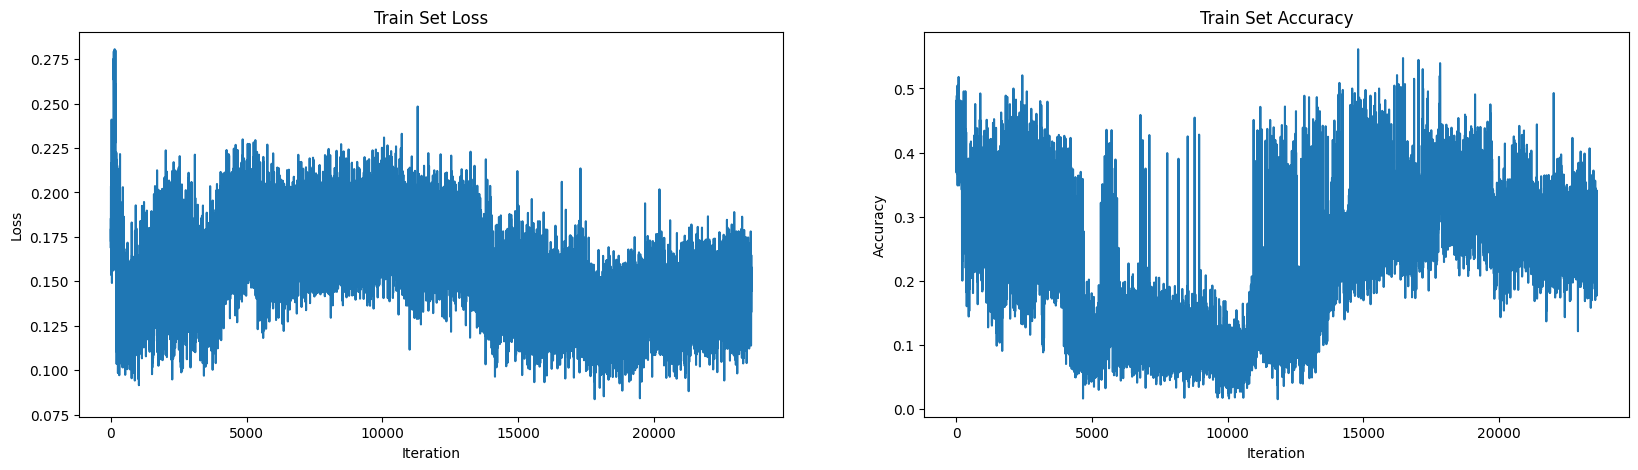

In [64]:
import matplotlib.pyplot as plt
# Plot Loss and Accuracy side-by-side
plt.figure(figsize=(20, 5), facecolor="w")

plt.subplot(1, 2, 1)
plt.plot(loss_hist, label="Train Set Loss")
plt.title("Train Set Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")


plt.subplot(1, 2, 2)
plt.plot(acc_hist, label="Train Set Accuracy")
plt.title("Train Set Accuracy")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.show()

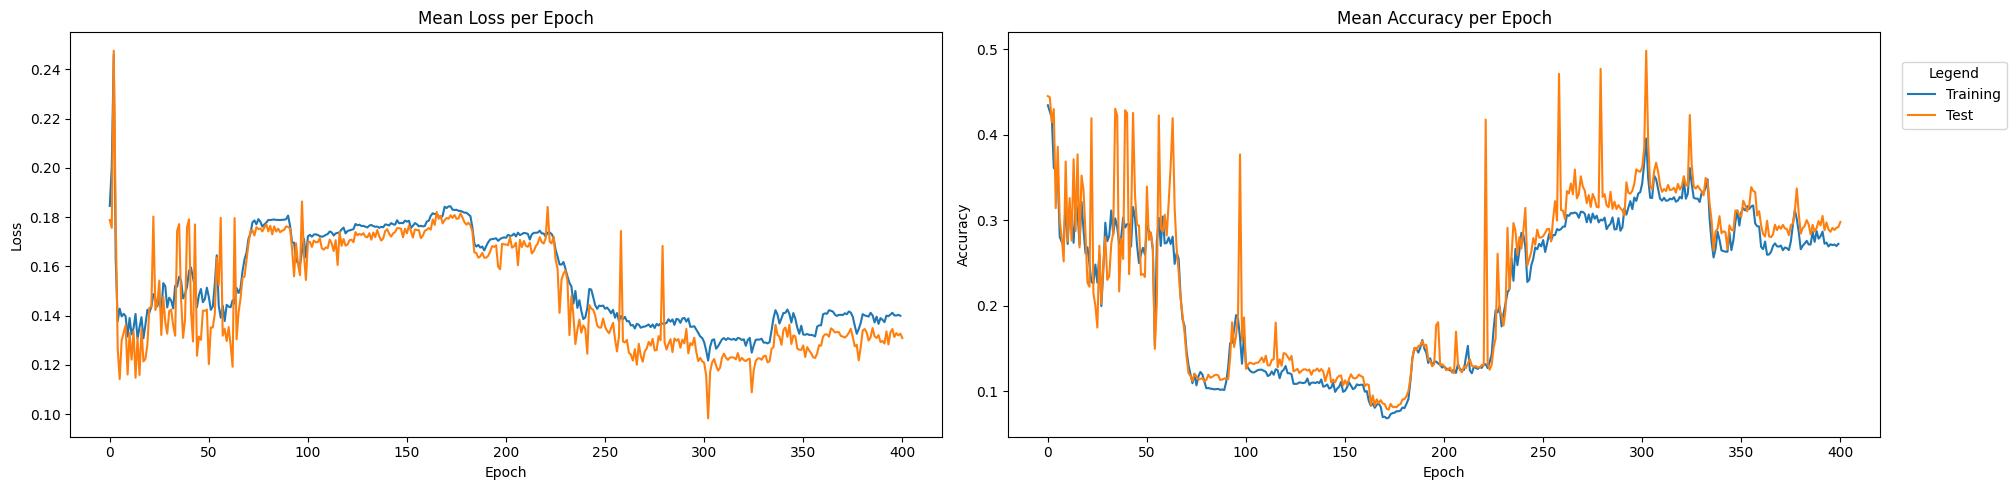

In [65]:
# Plot Mean Epoch Loss and Accuracy
# Plot Loss and Accuracy side-by-side
# Create the figure and axes
fig, axes = plt.subplots(1, 2, figsize=(20, 5), facecolor="w", sharey=False)

# Colors
train_color = "#1f77b4"
test_color = "#ff7f0e"

# Plot Loss
axes[0].plot(epoch_mean_loss, color=train_color, )
axes[0].plot(test_epoch_mean_loss, color=test_color, )
axes[0].set_title("Mean Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

# Plot Accuracy
axes[1].plot(epoch_mean_acc, color=train_color,)
axes[1].plot(test_epoch_mean_acc, color=test_color, )
axes[1].set_title("Mean Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

# Create one shared legend for both plots
lines = [
    plt.Line2D([0], [0], color=train_color, label='Training'),
    plt.Line2D([0], [0], color=test_color, label='Test')
]

fig.legend(
    handles=lines,
    loc='center left',
    bbox_to_anchor=(0.95, 0.8),
    borderaxespad=0.5,
    frameon=True,
    title="Legend"
)

# Adjust layout
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()


In [66]:
print(epoch_mean_loss)
print(epoch_mean_acc)

print(test_epoch_mean_loss)
print(test_epoch_mean_acc)

[0.1845135117991496, 0.2006168335171069, 0.2458904410822917, 0.16284841248544596, 0.1376666018770913, 0.1428034931926404, 0.13963998892044616, 0.14072561604996858, 0.13970074714240382, 0.13150480351710725, 0.13899695911144805, 0.13234285176810573, 0.1348750082365537, 0.14066091495550284, 0.13060787560070974, 0.13516538122952995, 0.13934595554561938, 0.1307765822541916, 0.13637687392153983, 0.1423980400471364, 0.14123358817423803, 0.14359187145354385, 0.14872526036480727, 0.1469178995338537, 0.14374303678839895, 0.14694871930247647, 0.14114955320196637, 0.15317754447460175, 0.15197201477268996, 0.14332437490002584, 0.1472779878620374, 0.14606692086336975, 0.14292496922662704, 0.15211639565936588, 0.15171408350184812, 0.15580538458238213, 0.1540690690784131, 0.14696710809307584, 0.14880654986126948, 0.15171914307747858, 0.1581361262222468, 0.15951873147386617, 0.1552726974931814, 0.1515378940661075, 0.14337492317466413, 0.1483489906383773, 0.1507848681787313, 0.14542120594089314, 0.14676

In [67]:
# Print loss statistics
print(f"Train Loss Statistics: Min={np.min(loss_hist)} | Max={np.max(loss_hist)} | Mean={np.mean(loss_hist)}")

# Print accuracy statistics
print(f"Train Accuracy Statistics: Min={np.min(acc_hist)} | Max={np.max(acc_hist)} | Mean={np.mean(acc_hist)}")

# Print F1 Score statistics
if len(f1_hist) > 0:
    print(f"Train F1 Score Statistics: Min={np.min(f1_hist)} | Max={np.max(f1_hist)} | Mean={np.mean(f1_hist)}")

# Print how the loss evolves over time
num_iters = len(loss_hist)
window_step = 100
for train_window in range(0, num_iters, window_step):
    print(f"Train Window [{train_window}, {train_window+window_step}]: Avg. Loss={np.mean(loss_hist[train_window:train_window+window_step]):.4f}")

Train Loss Statistics: Min=0.08371412009000778 | Max=0.28054478764533997 | Mean=0.15432300159455103
Train Accuracy Statistics: Min=0.014814814552664757 | Max=0.5613207817077637 | Mean=0.22142251159380175
Train Window [0, 100]: Avg. Loss=0.1846
Train Window [100, 200]: Avg. Loss=0.2293
Train Window [200, 300]: Avg. Loss=0.1430
Train Window [300, 400]: Avg. Loss=0.1416
Train Window [400, 500]: Avg. Loss=0.1415
Train Window [500, 600]: Avg. Loss=0.1331
Train Window [600, 700]: Avg. Loss=0.1357
Train Window [700, 800]: Avg. Loss=0.1367
Train Window [800, 900]: Avg. Loss=0.1322
Train Window [900, 1000]: Avg. Loss=0.1397
Train Window [1000, 1100]: Avg. Loss=0.1316
Train Window [1100, 1200]: Avg. Loss=0.1430
Train Window [1200, 1300]: Avg. Loss=0.1419
Train Window [1300, 1400]: Avg. Loss=0.1467
Train Window [1400, 1500]: Avg. Loss=0.1492
Train Window [1500, 1600]: Avg. Loss=0.1409
Train Window [1600, 1700]: Avg. Loss=0.1527
Train Window [1700, 1800]: Avg. Loss=0.1455
Train Window [1800, 1900]

In [68]:
# Plot the Loss in Bokeh
from snnTorch.utils.bokeh_plots import create_line_plot
import bokeh.plotting as bplt
from bokeh.io import output_notebook, output_file

# output_notebook()   # Show the plot in the notebook

y_arrays_loss = [(loss_hist, "Loss History")]

loss_plot = create_line_plot(
    title="Training Loss", x_axis_label="Iteration", y_axis_label="Loss",
    x=list(range(len(loss_hist))), y_arrays=y_arrays_loss,
    sizing_mode="fixed",        # stretch_both
    tooltips="Data point @x: @y",
    legend_location="top_right",
    legend_bg_fill_color="navy",
    legend_bg_fill_alpha=0.1,
)

In [69]:
showPlot = True
if showPlot:
    bplt.show(loss_plot)

# Clear the Bokeh Plots
bplt.curdoc().clear()

## Output Neurons Spiking behavior to a Test Input
Let's visualize the output neurons' spiking behavior when we feed a test input to the network of each Class Type

In [70]:
# Define Loss Function for testing. No Penalty and higher tolerance.
#TODO # Is it okay to use a different loss function for testing?


# loss_fn_test = SF.mse_temporal_loss(
#     target_is_time=True,
#     tolerance=PRED_GT_TOLERANCE * 1.5,       # Tolerance for the mse loss (in timesteps). If the output neuron spikes within this tolerance, the loss is 0
#     reduction='mean',        # Average the loss across the batch
# )
loss_fn_test=loss_fn

### Output Behavior for GT -1 -> No HFO


In [71]:
net.eval()  # Set the network to evaluation mode

test_no_hfo_input, test_no_hfo_gt = None, None
for test_batch, test_gt_batch in iter(test_loader):
    # Check if current batch has an input without an HFO
    test_no_hfo_input_idx = torch.argmin(test_gt_batch).item()
    if test_gt_batch[test_no_hfo_input_idx] < 0:
        # Found a batch without an HFO
        # Get the input data and ground truth for the test batch
        test_no_hfo_input = test_batch[test_no_hfo_input_idx]
        test_no_hfo_gt = test_gt_batch[test_no_hfo_input_idx]
        break

if test_no_hfo_input is None:
    print("No Batch without a HFO found in the Test Set!")
    exit()

# Add a batch dimension to the input data. Shape: (1, num_steps)
test_no_hfo_input = test_no_hfo_input.unsqueeze(0)
test_no_hfo_gt = test_no_hfo_gt.unsqueeze(0)

print("Found batch with Ground Truth: ", test_no_hfo_gt)
print(f"test_no_hfo_input shape = {test_no_hfo_input.shape}")
print(f"Number of UP spikes in the batch: {torch.sum(test_no_hfo_input[:, :,0])}")
print(f"Number of DN spikes in the batch: {torch.sum(test_no_hfo_input[:, :, 1])}")
print(f"test_no_hfo_gt shape = {test_no_hfo_gt.shape}")

test_no_hfo_input = test_no_hfo_input.to(device)    # Send the test data to the device
test_no_hfo_gt = test_no_hfo_gt.to(device)        # Send the test ground truth to the device

# Feed the test batch through the network
test_spks, test_mem, test_cur = net(test_no_hfo_input)

Found batch with Ground Truth:  tensor([-1.])
test_no_hfo_input shape = torch.Size([1, 200, 2])
Number of UP spikes in the batch: 1.0
Number of DN spikes in the batch: 0.0
test_no_hfo_gt shape = torch.Size([1])


No HFO Event
input_spike_times: [array([9], dtype=int64), array([], dtype=int64)]


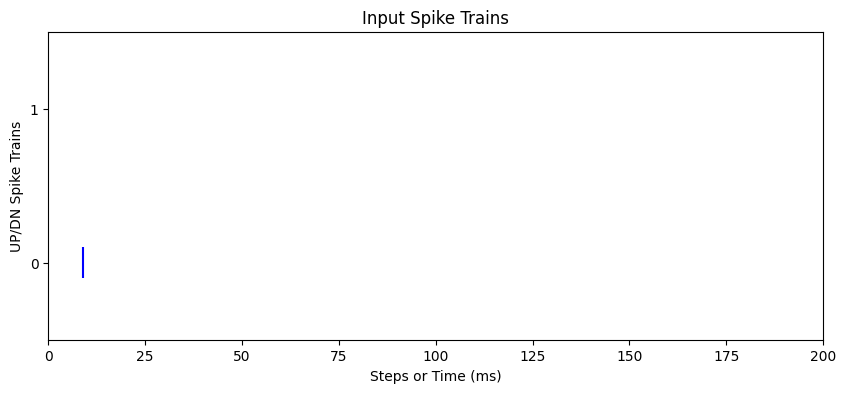

In [72]:
from snnTorch.utils.hfo import input_sample_to_spike_raster


# Creates a Figure and Axis objects
fig, ax = input_sample_to_spike_raster(
    test_no_hfo_input[0, :, :].cpu().detach().numpy(),
    test_no_hfo_gt[0].cpu().detach().numpy(),
    PRED_GT_TOLERANCE,
    verbose=True
)

# Show the plot
plt.show()

In [73]:
# Extract the output spikes of the network
out_spks = test_spks[-1]

# Calculate the Loss and Accuracy
test_no_hfo_gt = test_no_hfo_gt.clone().unsqueeze(1)   # Add num_features dimension to the ground truth tensor
loss_val = loss_fn_test(out_spks, test_no_hfo_gt.clone())   # Copy the ground truth to avoid modifying it in place
acc_val = first_spike_acc(out_spks, test_no_hfo_gt, tolerance=PRED_GT_TOLERANCE, verbose=False)

# Remove the batch dimension
out_spks = out_spks.squeeze(1)  # Resulting Shape = (num_steps, num_neurons)

print(f"out_spks Shape: {out_spks.shape}")
print(f"Number of output spikes per class: {torch.sum(out_spks[:, 0])}")
print(f"Loss: {loss_val.item()} | Accuracy: {acc_val.item()}")

out_spks Shape: torch.Size([205, 1])
Number of output spikes per class: 0.0
Loss: 0.0 | Accuracy: 1.0


In [74]:
# from IPython.display import HTML
# from snntorch import spikeplot as splt

# idx = 0     # Choose a sample from the batch to visualize (only 1 sample in the batch)

# fig, ax = plt.subplots(facecolor='w', figsize=(12, 7))

# # Define the labels for the classes
# # Single Neuron -> HFO Detected
# labels=['HFO']

# print(f"The target label is: {int(test_no_hfo_gt.sum() > 0)}")

# # plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'

# #  Plot spike count histogram
# anim = splt.spike_count(out_spks.detach().cpu(), fig, ax, labels=labels, 
#                         animate=True, interpolate=1)

# HTML(anim.to_html5_video())
# # anim.save("spike_bar.mp4")

### Output Behavior for GT > 0 -> HFO at a given timestep


In [75]:
net.eval()  # Set the network to evaluation mode

test_hfo_input, test_hfo_gt = None, None
for test_batch, test_gt_batch in iter(test_loader):
    for i in range(test_gt_batch.shape[0]):
        gt_time = test_gt_batch[i].item()
        if 0 < gt_time < WINDOW_SIZE:
            test_hfo_input = test_batch[i]
            test_hfo_gt = test_gt_batch[i]
            break

if test_hfo_input is None:
    print("No Batch with an HFO found in the Test Set!")
    exit()

# Add a batch dimension to the input data. Shape: (1, num_steps)
test_hfo_input = test_hfo_input.unsqueeze(0)
test_hfo_gt = test_hfo_gt.unsqueeze(0)

print("Found batch with Ground Truth: ", test_hfo_gt)
print(f"test_hfo_input shape = {test_hfo_input.shape}")
print(f"Number of input spikes in the batch: {torch.sum(test_hfo_input)}")

test_hfo_input = test_hfo_input.to(device)    # Send the test data to the device
test_hfo_gt = test_hfo_gt.to(device)        # Send the test ground truth to the device

# Feed the test batch through the network
test_spks, test_mem, test_cur = net(test_hfo_input)

Found batch with Ground Truth:  tensor([28.])
test_hfo_input shape = torch.Size([1, 200, 2])
Number of input spikes in the batch: 5.0


GT Interval: 8.0 to 48.0
input_spike_times: [array([ 63, 157], dtype=int64), array([ 22,  27, 172], dtype=int64)]


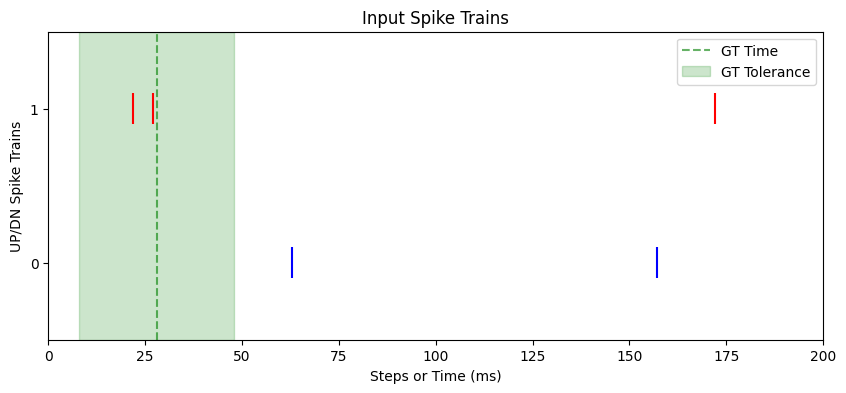

In [76]:
# Creates a Figure and Axis objects
fig, ax = input_sample_to_spike_raster(
    test_hfo_input[0, :, :].cpu().detach().numpy(),
    test_hfo_gt[0].cpu().detach().numpy(),
    PRED_GT_TOLERANCE,
    verbose=True
)

# Show the plot
plt.show()

In [77]:
# Extract the output spikes of the network
out_spks = test_spks[-1]

# Calculate the Loss and Accuracy
test_hfo_gt = test_hfo_gt.clone().unsqueeze(1)   # Add num_features dimension to the ground truth tensor
loss_val = loss_fn_test(out_spks, test_hfo_gt.clone())   # Copy the ground truth to avoid modifying it in place
acc_val = first_spike_acc(out_spks, test_hfo_gt, tolerance=PRED_GT_TOLERANCE, verbose=False)

# Remove the batch dimension
out_spks = out_spks.squeeze(1)  # Resulting Shape = (num_steps, num_neurons)

print(f"out_spks Shape: {out_spks.shape}")
print(f"Number of output spikes per class: {torch.sum(out_spks[:, 0])}")
print(f"First Out Spike Time: {torch.argmax(out_spks[:, 0])}")
print(f"Loss: {loss_val.item()} | Accuracy: {acc_val.item()}")

out_spks Shape: torch.Size([205, 1])
Number of output spikes per class: 0.0
First Out Spike Time: 0
Loss: 0.7370851039886475 | Accuracy: 0.0


In [78]:
# from IPython.display import HTML
# from snntorch import spikeplot as splt

# idx = 0     # Choose a sample from the batch to visualize (only 1 sample in the batch)

# fig, ax = plt.subplots(facecolor='w', figsize=(12, 7))

# print(f"The target label is: {test_hfo_gt.sum() > 0}")

# # Define the labels for the classes
# # Single Neuron -> HFO Detected
# labels=['HFO']

# # plt.rcParams['animation.ffmpeg_path'] = 'C:\\path\\to\\your\\ffmpeg.exe'

# #  Plot spike count histogram
# anim = splt.spike_count(out_spks.detach().cpu(), fig, ax, labels=labels, 
#                         animate=True, interpolate=1)

# HTML(anim.to_html5_video())
# # anim.save("spike_bar.mp4")

## Show the Trained Network Parameters
Show the trained parameters and calculate the parameter difference

In [79]:
# Display the network architecture
total_params = 0    # Accumulator for the total params in the network
# Iterate through the layers of the network
for idx, (name, param) in enumerate(net.named_parameters()):
    untrained_param = untrained_params[idx]

    # print("param: ", param)
    if param.shape == torch.Size([]):
        print(f"Scalar Param ({name}) | Shape={param.shape} | Param Diff: {torch.sum(torch.abs(param - untrained_param)).item()} | Value={param} \n")
    elif len(param.shape) == 1:
        print(f"Vector Param ({name}) | Shape={param.shape} | Param Diff: {torch.sum(torch.abs(param - untrained_param)).item()} | Value={param} \n")
    else:
        print(f"Tensor Param ({name}) | Shape={param.shape}. Total={param.numel()} | Param Diff: {torch.sum(torch.abs(param - untrained_param)).item()} | Preview: {param[:8, :8]}\n")

    # Add the number of parameters in the layer to the total
    total_params += param.numel()

# Print the total number of parameters in the network
print(f"Total Parameters: {total_params}")

Tensor Param (fc_in.weight) | Shape=torch.Size([8, 2]). Total=16 | Param Diff: 2.0368874073028564 | Preview: tensor([[ 1.3589,  1.6524],
        [ 1.3108,  1.4841],
        [ 0.9769,  0.9315],
        [ 1.7103,  1.5168],
        [ 1.5763, -0.1713],
        [-0.1028,  1.0203],
        [-0.2966,  1.3746],
        [ 1.3409, -0.0404]], grad_fn=<SliceBackward0>)

Vector Param (lif1.beta) | Shape=torch.Size([8]) | Param Diff: 0.24849551916122437 | Value=Parameter containing:
tensor([0.6329, 0.3216, 0.4989, 0.6847, 0.5815, 0.3569, 0.6496, 0.5909],
       requires_grad=True) 

Vector Param (lif1.alpha) | Shape=torch.Size([8]) | Param Diff: 0.21092060208320618 | Value=Parameter containing:
tensor([0.4126, 0.4049, 0.4485, 0.6530, 0.5168, 0.8968, 0.2448, 0.3414],
       requires_grad=True) 

Tensor Param (fc3.weight) | Shape=torch.Size([6, 8]). Total=48 | Param Diff: 1.7908154726028442 | Preview: tensor([[ 1.2224, -0.2194, -0.4675, -0.0229, -0.2255,  1.2816, -0.2493,  1.2473],
        [ 1.2520, -

In [80]:
# Save the trained network to a file
SAVE_TRAINED_NETWORK = False
prefix="test_mesquita"
if SAVE_TRAINED_NETWORK:
    os.makedirs("./out",exist_ok=True)  # Create the output directory if it doesn't exist 
    torch.save(net.state_dict(), f"./out/{prefix}_trained_net_loss.pth") # trained_net_loss_penalty.pth

## Test the Network on the Test Set
#### Load a Trained Network Model for Testing

In [81]:
# Load a network from a file
LOAD_TRAINED_NETWORK = False
if LOAD_TRAINED_NETWORK:
    filename = f"./out/{prefix}_trained_net_loss.pth"     # "./trained_net_loss_penalty.pth"
    net.load_state_dict(torch.load(filename))
    

In [82]:
# LOAD_BEST_STATE=True
# LOAD_FINAL_STATE=False

LOAD_BEST_STATE=False
LOAD_FINAL_STATE=True

if LOAD_BEST_STATE and not LOAD_FINAL_STATE:
    filename = f"./nets/best_model_state.pth"
    net.load_state_dict(torch.load(filename))
    print(f"Loaded Best Model State from {filename}")
elif LOAD_FINAL_STATE and not LOAD_BEST_STATE:
    filename = f"./nets/final_model_state.pth"
    net.load_state_dict(torch.load(filename))
    print(f"Loaded Final Model State from {filename}")
else:
    print("Nothing Loaded!")

Loaded Final Model State from ./nets/final_model_state.pth


In [83]:
# Test the network on the entire test set
#Set Shuffle to False to evaluate the model on the entire test set
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

detection_window = (PRED_GT_TOLERANCE,PRED_GT_TOLERANCE) #+PRED_GT_TOLERANCE # Number of time steps allowed after GT
from utils.permutation_test import *
TP,FP,FN,TN,test_loss_hist,test_acc_hist,first_spike_times=evaluate_model(test_loader,net,forward_step,device,detection_window)



In [84]:
# Print loss statistics
print(f"Test Loss Statistics: Min={np.min(test_loss_hist)} | Max={np.max(test_loss_hist)} | Mean={np.mean(test_loss_hist)}")

# Print accuracy statistics
print(f"Test Accuracy Statistics: Min={np.min(test_acc_hist)} | Max={np.max(test_acc_hist)} | Mean={np.mean(test_acc_hist)}")

Test Loss Statistics: Min=0.10763067752122879 | Max=0.15081314742565155 | Mean=0.13139435987580905
Test Accuracy Statistics: Min=0.25984251499176025 | Max=0.3392857015132904 | Mean=0.295610864054073


In [85]:
# Show the Confusion Matrix
print(f"Confusion Matrix:")

# Print lines with same width
print(f"|TP: {TP} | FP: {FP}|\n|FN: {FN}  | TN: {TN}|")

Confusion Matrix:
|TP: 213 | FP: 66|
|FN: 1116  | TN: 1271|


In [86]:
precision = TP / (TP + FP + 1e-10)
recall = TP / (TP + FN + 1e-10)
f1 = 2 * precision * recall / (precision + recall + 1e-10)
false_positive_rate = FP / (FP + TN + 1e-10)
accuracy_overall = (TP + TN) / (TP + FP + FN + TN + 1e-10)
print(f"\nPrecision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f} | \nFalse Positive Rate: {false_positive_rate:.4f} | Accuracy: {accuracy_overall:.4f}")
print(f"TP: {TP} | FP: {FP} | FN: {FN} | TN: {TN}")


Precision: 0.7634 | Recall: 0.1603 | F1 Score: 0.2649 | 
False Positive Rate: 0.0494 | Accuracy: 0.5566
TP: 213 | FP: 66 | FN: 1116 | TN: 1271


In [87]:
TP,FP,FN,TN,test_loss_hist,test_acc_hist,first_spike_times=evaluate_model(test_loader,net,forward_step,device,detection_window,only_spiked=True)
# Show the Confusion Matrix
precision = TP / (TP + FP + 1e-10)
recall = TP / (TP + FN + 1e-10)
f1 = 2 * precision * recall / (precision + recall + 1e-10)
false_positive_rate = FP / (FP + TN + 1e-10)
accuracy_overall = (TP + TN) / (TP + FP + FN + TN + 1e-10)
print(f"\nPrecision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f} | \nFalse Positive Rate: {false_positive_rate:.4f} | Accuracy: {accuracy_overall:.4f}")
print(f"TP: {TP} | FP: {FP} | FN: {FN} | TN: {TN}")


Precision: 0.8900 | Recall: 0.4018 | F1 Score: 0.5537 | 
False Positive Rate: 0.0494 | Accuracy: 0.6770
TP: 534 | FP: 66 | FN: 795 | TN: 1271


In [88]:
# actual_score, null_distribution, p_value=permutation_test(test_loader,first_spike_times,detection_window, N=1000)
# print(f"Actual Score: {actual_score:.4f} | Null Distribution Mean: {np.mean(null_distribution):.4f} | P-Value: {p_value:.4f}")

In [ ]:
# plt.figure(figsize=(10, 5), facecolor="w")
# plt.hist(null_distribution, bins=50, alpha=0.5, label='Null Distribution', color='blue')
# plt.axvline(actual_score, color='red', linestyle='dashed', linewidth=2, label=f'Actual Score - p={p_value:.3f}')
# plt.title('Permutation Test Results')
# plt.xlabel('F1 Score')
# plt.ylabel('Frequency')
# plt.legend()
# plt.show()



## Define the Device that will be used to train the SNN


In [ ]:
# actual_score_t, null_distribution_t, p_value_t=permutation_test_accurate_targets(test_loader,first_spike_times,detection_window, N=1000)
# print(f"Actual Score: {actual_score_t:.4f} | Null Distribution Mean: {np.mean(null_distribution_t):.4f} | P-Value: {p_value_t:.4f}")

In [ ]:
# plt.figure(figsize=(10, 5), facecolor="w")
# plt.hist(null_distribution_t, bins=50, alpha=0.5, label='Null Distribution', color='blue')
# plt.axvline(actual_score_t, color='red', linestyle='dashed', linewidth=2, label=f'Actual Score - p={p_value_t:.3f}')
# plt.title('Permutation Test Results')
# plt.xlabel('F1 Score')
# plt.ylabel('Frequency')
# plt.legend()
# plt.show()

In [ ]:
# Save the trained network to a file
SAVE_TRAINED_NETWORK =False
# prefix="dsb4updn_median_200_16f"
# prefix="updnb4ds_100_14b"
# prefix="adapt20_3f"
prefix="iiss_6f"
if SAVE_TRAINED_NETWORK:
    os.makedirs("./out",exist_ok=True)  # Create the output directory if it doesn't exist 
    torch.save(net.state_dict(), f"./out/{prefix}_trained_net_loss.pth") # trained_net_loss_penalty.pth
    print(f"Trained network saved to ./out/{prefix}_trained_net_loss.pth")

Trained network saved to ./out/iiss_6f_trained_net_loss.pth


In [352]:
save_stats = False
save_path_distribution=os.path.join(curr_dir,"eval","windowed_distribition")
os.makedirs(save_path_distribution, exist_ok=True)
if save_stats:
    results = {
    "actual_score": actual_score,
    "p_value": p_value,
    "p_value_t": p_value_t,
    "recall": recall,
    "precision": precision,
    "f1_score": f1,
    "false_positive_rate": false_positive_rate,
    "accuracy_overall": accuracy_overall,
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "TN": TN,
    }
    path= os.path.join(save_path_distribution, f"{prefix}_results.json")
    with open(path, "w") as f:
        json.dump(results, f,indent=4)